### `Powershell Commands`

In [ ]:
.\test_lab\testlab\Scripts\activate
& "$env:LOCALAPPDATA\Programs\nu\bin\nu.exe"

aria2c -c -x9 -s9 -d "downloads" "URL"
7z x "C:\Users\ritwi\Downloads\Foxit_PDF_Editor_Pro_v2025.1.0.27937.rar"


### `yt-download`

In [ ]:
import os
import sys
import yt_dlp

# Constants for ease of use
video = 'video'
music = 'music'

def download_media(query_or_url, mode):
    """
    Downloads media from YouTube using yt-dlp based on mode.
    """
    # Ensure the directory exists
    os.makedirs('./downloads', exist_ok=True)

    if mode == music:
        print("Mode: MUSIC (Best Quality Audio 320kbps)")
        ydl_opts = {
        'format': 'bestaudio/best',
        'outtmpl': './downloads/%(title)s.%(ext)s',
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
            'preferredquality': '320',
        }, {
            'key': 'EmbedThumbnail',
        }, {
            'key': 'FFmpegMetadata',
        }],
        'logger': MyLogger(),
        'progress_hooks': [my_hook],
        'writethumbnail': True,
        'remote_components': 'ejs:github',
        }
    elif mode == video:
        print("Mode: VIDEO (Best Quality Video + Audio)")
        # 'bestvideo+bestaudio/best' ensures no compromise on quality
        # Video and Audio will be downloaded separately at maximum quality and merged
        ydl_opts = {
        'format': 'bestvideo+bestaudio/best',
        'outtmpl': './downloads/%(title)s.%(ext)s',
        'postprocessors': [{
            'key': 'EmbedThumbnail',
        }, {
            'key': 'FFmpegMetadata',
        }],
        'logger': MyLogger(),
        'progress_hooks': [my_hook],
        'writethumbnail': True,
        # mkv safely merges any two formats without lossy re-encoding
        'merge_output_format': 'mkv',
        'remote_components': 'ejs:github', 
        }
    else:
        print(f"Error: Invalid mode '{mode}'. Set it to music or video.")
        return

    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            if not query_or_url.startswith(('http://', 'https://')):
                print(f"Searching for: {query_or_url}")
                ydl.download([f"ytsearch1:{query_or_url}"])
            else:
                print(f"Downloading from URL: {query_or_url}")
                ydl.download([query_or_url])
    except Exception as e:
        print(f"Error: {e}")

class MyLogger(object):
    def debug(self, msg):
        pass

    def warning(self, msg):
        print(f"Warning: {msg}")

    def error(self, msg):
        print(f"Error: {msg}")

def my_hook(d):
    if d['status'] == 'finished':
        print(f"\nDone downloading, now processing...")
    if d['status'] == 'downloading':
        sys.stdout.write(f"\rDownloading: {d.get('_percent_str', 'N/A')}   ")
        sys.stdout.flush()

def main(url, mode):
    """
    Trigger the download for the given URL and mode.
    """
    print("--- Master YouTube Downloader ---")
    if url and url != "YOUR_URL_HERE":
        download_media(url, mode)
    else:
        print("No valid URL provided. Please replace 'YOUR_URL_HERE' with a real URL.")

if __name__ == "__main__":
    main("YOUR_URL_HERE", video)


### `Garden`

<img src="images/Dream.png" width="1711">


<img src="images/RDR2.png" width="1711">

# <span style="background-color:green; color:black">LATEX</span>



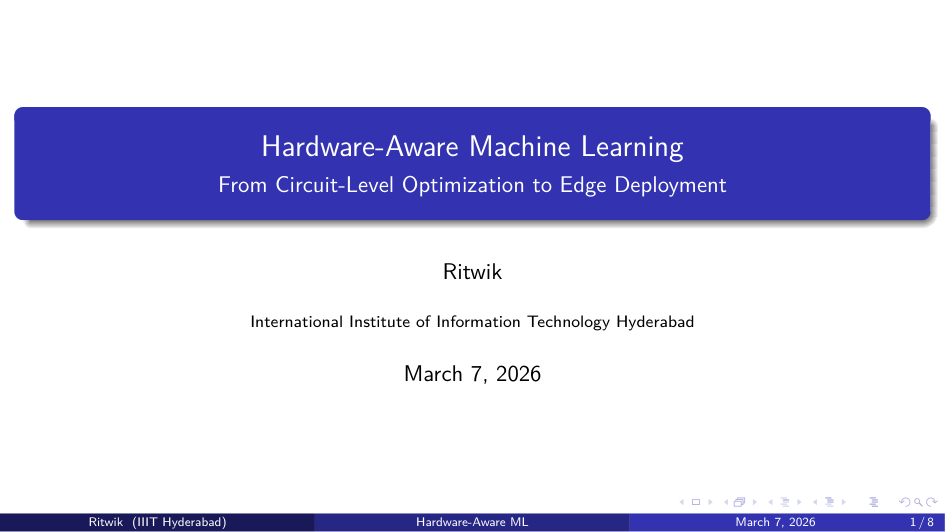

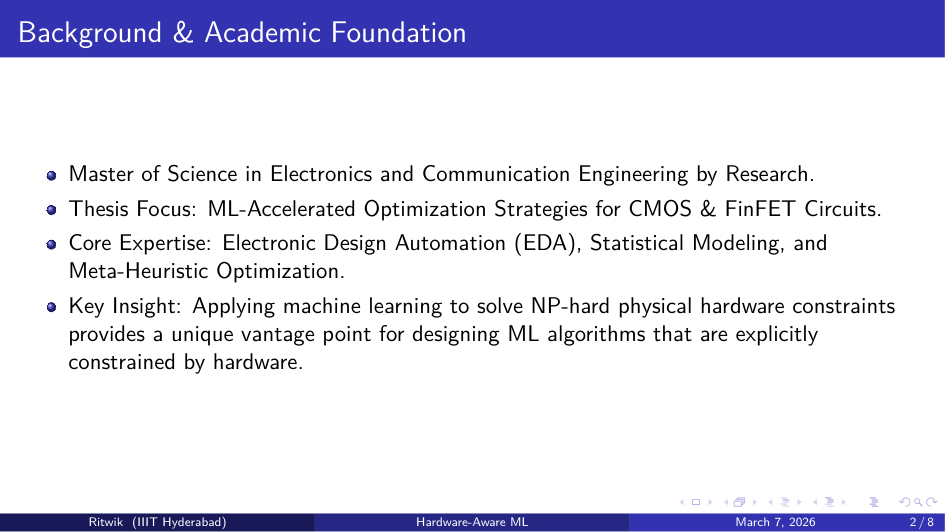

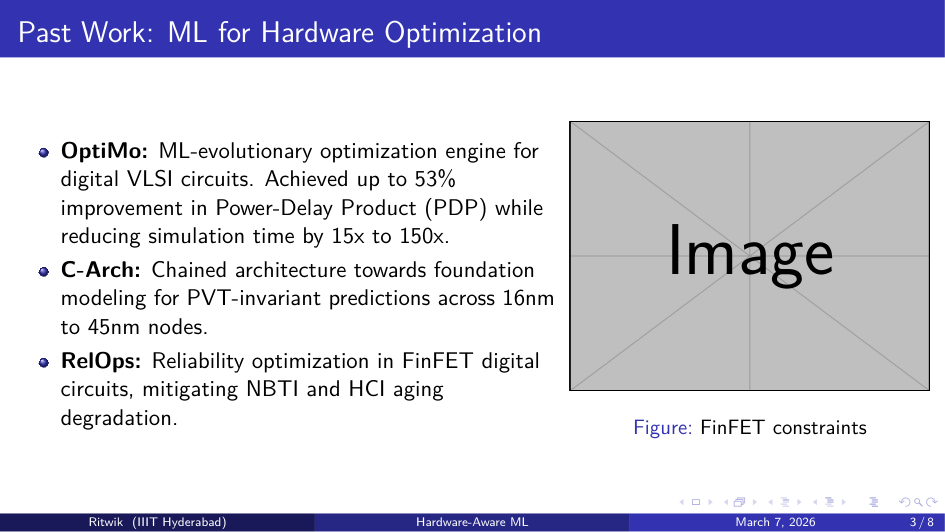

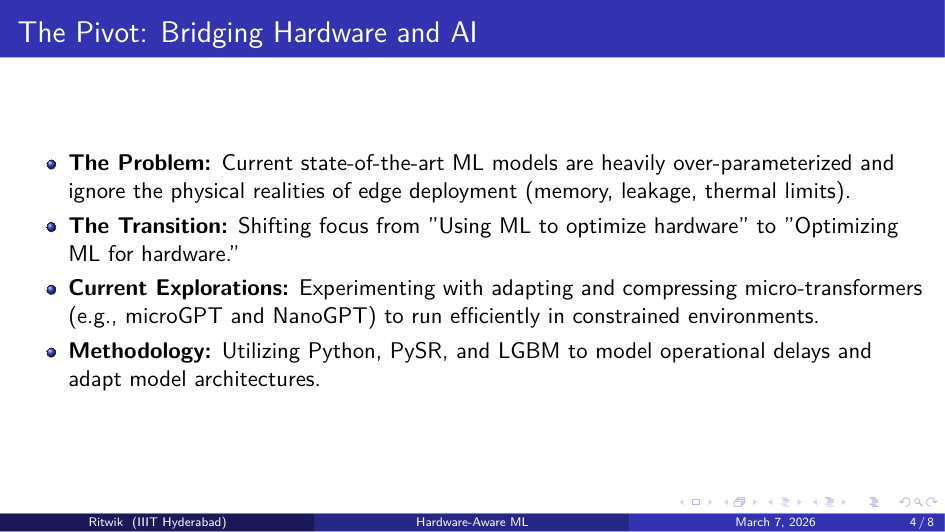

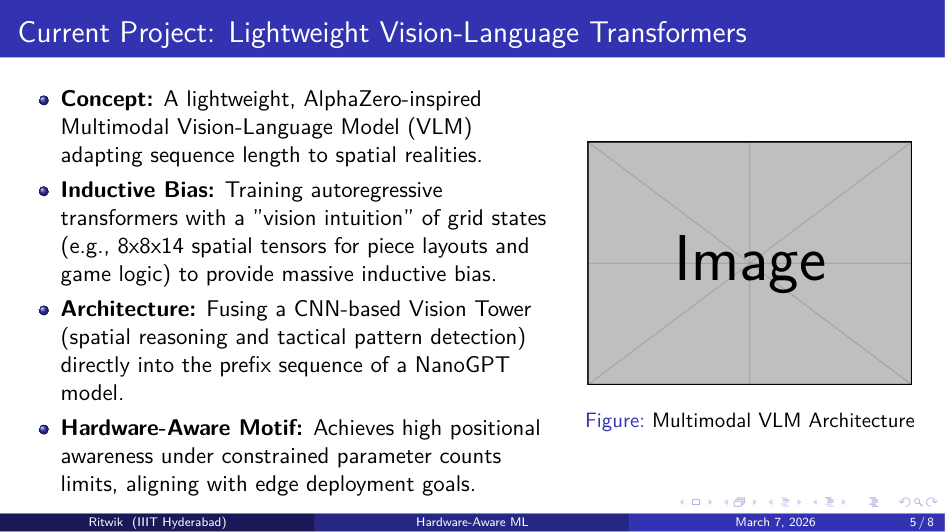

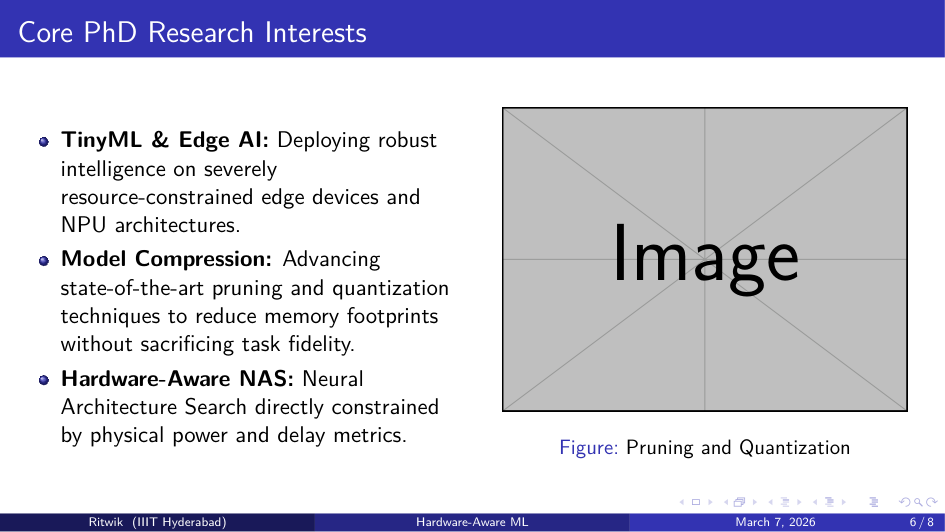

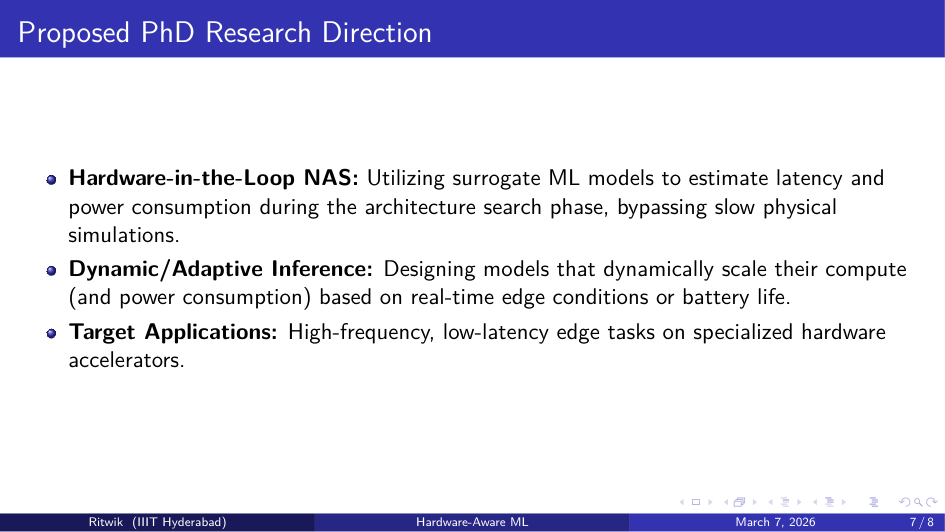

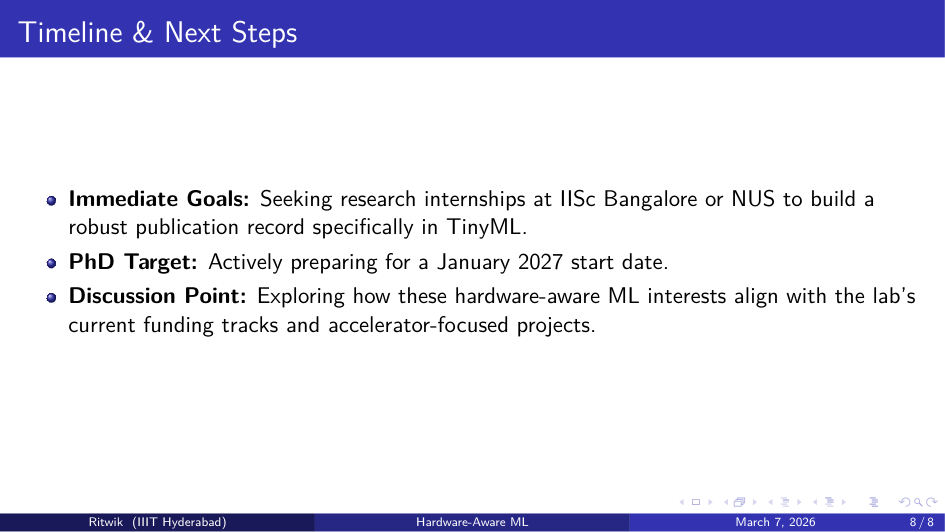

In [8]:
import fitz # PyMuPDF
from IPython.display import display
from PIL import Image

# Add an 'r' before the string quotes
doc = fitz.open(r'D:\QCSARE\LaTeX_Presentation\presentation_rectified.pdf')

# Render each slide and display it
for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    
    # Get a high-resolution pixmap of the page
    pix = page.get_pixmap(dpi=150)
    
    # Convert it to a PIL Image so Jupyter knows how to display it natively
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    
    # Display the image inline
    display(img)


### `.tex`

In [ ]:
\documentclass[aspectratio=169]{beamer}
\usetheme{Madrid}
\usecolortheme{default}
\usepackage{graphicx}

\title[Hardware-Aware ML]{Hardware-Aware Machine Learning}
\subtitle{From Circuit-Level Optimization to Edge Deployment}
\author{Ritwik}
\institute[IIIT Hyderabad]{International Institute of Information Technology Hyderabad}
\date{\today}

\begin{document}

\begin{frame} \relax
    \titlepage
\end{frame}

\begin{frame} \relax
    \frametitle{Background \& Academic Foundation} \relax
    \begin{itemize} \relax
        \item \relax {Master of Science in Electronics and Communication Engineering by Research.}
        \item \relax {Thesis Focus: ML-Accelerated Optimization Strategies for CMOS \& FinFET Circuits.}
        \item \relax {Core Expertise: Electronic Design Automation (EDA), Statistical Modeling, and Meta-Heuristic Optimization.}
        \item \relax {Key Insight: Applying machine learning to solve NP-hard physical hardware constraints provides a unique vantage point for designing ML algorithms that are explicitly constrained by hardware.}
    \end{itemize}
\end{frame}

\begin{frame} \relax
    \frametitle{Past Work: ML for Hardware Optimization} \relax
    \begin{columns}
        \begin{column}{0.6\textwidth}
            \begin{itemize} \relax
                \item \relax {\textbf{OptiMo:} ML-evolutionary optimization engine for digital VLSI circuits. Achieved up to 53\% improvement in Power-Delay Product (PDP) while reducing simulation time by 15x to 150x.}
                \item \relax {\textbf{C-Arch:} Chained architecture towards foundation modeling for PVT-invariant predictions across 16nm to 45nm nodes.}
                \item \relax {\textbf{RelOps:} Reliability optimization in FinFET digital circuits, mitigating NBTI and HCI aging degradation.}
            \end{itemize}
        \end{column}
        \begin{column}{0.4\textwidth}
            \begin{figure}
                \centering
                % Insert image here: A diagram of a CMOS FinFET transistor architecture
                \includegraphics[width=\textwidth]{example-image}
                \caption{FinFET constraints}
            \end{figure}
        \end{column}
    \end{columns}
\end{frame}

\begin{frame} \relax
    \frametitle{The Pivot: Bridging Hardware and AI} \relax
    \begin{itemize} \relax
        \item \relax {\textbf{The Problem:} Current state-of-the-art ML models are heavily over-parameterized and ignore the physical realities of edge deployment (memory, leakage, thermal limits).}
        \item \relax {\textbf{The Transition:} Shifting focus from "Using ML to optimize hardware" to "Optimizing ML for hardware."}
        \item \relax {\textbf{Current Explorations:} Experimenting with adapting and compressing micro-transformers (e.g., microGPT and NanoGPT) to run efficiently in constrained environments.}
        \item \relax {\textbf{Methodology:} Utilizing Python, PySR, and LGBM to model operational delays and adapt model architectures.}
    \end{itemize}
\end{frame}

\begin{frame} \relax
    \frametitle{Current Project: Lightweight Vision-Language Transformers} \relax
    \begin{columns}
        \begin{column}{0.6\textwidth}
            \begin{itemize} \relax
                \item \relax {\textbf{Concept:} A lightweight, AlphaZero-inspired Multimodal Vision-Language Model (VLM) adapting sequence length to spatial realities.}
                \item \relax {\textbf{Inductive Bias:} Training autoregressive transformers with a "vision intuition" of grid states (e.g., 8x8x14 spatial tensors for piece layouts and game logic) to provide massive inductive bias.}
                \item \relax {\textbf{Architecture:} Fusing a CNN-based Vision Tower (spatial reasoning and tactical pattern detection) directly into the prefix sequence of a NanoGPT model.}
                \item \relax {\textbf{Hardware-Aware Motif:} Achieves high positional awareness under constrained parameter counts limits, aligning with edge deployment goals.}
            \end{itemize}
        \end{column}
        \begin{column}{0.4\textwidth}
            \begin{figure}
                \centering
                % Insert image here: A block diagram of the CNN Vision Tower prepending into the Transformer
                \includegraphics[width=0.9\textwidth]{example-image}
                \caption{Multimodal VLM Architecture}
            \end{figure}
        \end{column}
    \end{columns}
\end{frame}

\begin{frame} \relax
    \frametitle{Core PhD Research Interests} \relax
    \begin{columns}
        \begin{column}{0.5\textwidth}
            \begin{itemize} \relax
                \item \relax {\textbf{TinyML \& Edge AI:} Deploying robust intelligence on severely resource-constrained edge devices and NPU architectures.}
                \item \relax {\textbf{Model Compression:} Advancing state-of-the-art pruning and quantization techniques to reduce memory footprints without sacrificing task fidelity.}
                \item \relax {\textbf{Hardware-Aware NAS:} Neural Architecture Search directly constrained by physical power and delay metrics.}
            \end{itemize}
        \end{column}
        \begin{column}{0.5\textwidth}
            \begin{figure}
                \centering
                % Insert image here: A diagram of neural network pruning and quantization
                \includegraphics[width=0.9\textwidth]{example-image}
                \caption{Pruning and Quantization}
            \end{figure}
        \end{column}
    \end{columns}
\end{frame}

\begin{frame} \relax
    \frametitle{Proposed PhD Research Direction} \relax
    \begin{itemize} \relax
        \item \relax {\textbf{Hardware-in-the-Loop NAS:} Utilizing surrogate ML models to estimate latency and power consumption during the architecture search phase, bypassing slow physical simulations.}
        \item \relax {\textbf{Dynamic/Adaptive Inference:} Designing models that dynamically scale their compute (and power consumption) based on real-time edge conditions or battery life.}
        \item \relax {\textbf{Target Applications:} High-frequency, low-latency edge tasks on specialized hardware accelerators.}
    \end{itemize}
\end{frame}

\begin{frame} \relax
    \frametitle{Timeline \& Next Steps} \relax
    \begin{itemize} \relax
        \item \relax {\textbf{Immediate Goals:} Seeking research internships at IISc Bangalore or NUS to build a robust publication record specifically in TinyML.}
        \item \relax {\textbf{PhD Target:} Actively preparing for a January 2027 start date.}
        \item \relax {\textbf{Discussion Point:} Exploring how these hardware-aware ML interests align with the lab's current funding tracks and accelerator-focused projects.}
    \end{itemize}
\end{frame}

\end{document}


In [ ]:
"""
######################## PDF COMPILER ########################
"""
%%writefile playground.py
import os
import urllib.request
import zipfile
import subprocess
import sys

def download_and_extract_tectonic():
    tectonic_exe = "tectonic.exe"
    zip_filename = "tectonic.zip"
    url = "https://github.com/tectonic-typesetting/tectonic/releases/download/tectonic%400.15.0/tectonic-0.15.0-x86_64-pc-windows-msvc.zip"

    if os.path.exists(tectonic_exe):
        print("Tectonic is already downloaded.")
        return tectonic_exe

    print("Downloading Tectonic standalone LaTeX compiler (this will keep your system clean)...")
    try:
        urllib.request.urlretrieve(url, zip_filename)
        print("Download complete. Extracting...")
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall()
        os.remove(zip_filename)
        print("Extraction complete.")
        return tectonic_exe
    except Exception as e:
        print(f"Error downloading or extracting Tectonic: {e}")
        return None

def compile_latex(tex_file):
    tectonic_exe = download_and_extract_tectonic()
    if not tectonic_exe:
        print("Compilation aborted due to missing compiler.")
        return

    print(f"Compiling {tex_file}...")
    try:
        # Tectonic automatically downloads required LaTeX packages on the fly
        result = subprocess.run([tectonic_exe, tex_file], capture_output=True, text=True)
        if result.returncode == 0:
            pdf_file = tex_file.replace(".tex", ".pdf")
            print(f"Successfully compiled! PDF saved as {pdf_file}")
            # Try to open the PDF
            try:
                os.startfile(pdf_file)
            except Exception:
                print(f"Could not automatically open {pdf_file}. You can open it manually.")
        else:
            print("Compilation failed with errors:")
            print(result.stderr)
            print(result.stdout)
    except Exception as e:
        print(f"Error during compilation string execution: {e}")

if __name__ == "__main__":
    if len(sys.argv) > 1:
        tex_file = sys.argv[1]
    else:
        tex_file = "presentation_rectified.tex"
        
    compile_latex(tex_file)


In [ ]:
"""
########################## PDF to PPTX ########################## 
"""
%%writefile playground.py
import os
import sys
from pdf2image import convert_from_path
from pptx import Presentation
from pptx.util import Inches

def pdf_to_pptx(pdf_path, pptx_path):
    print(f"Converting PDF '{pdf_path}' to Images...")
    
    try:
        # Note: on Windows, poppler is required for pdf2image.
        # But since we are generating slides, let's try a fallback: PyMuPDF (fitz) is more self-contained.
        import fitz  # PyMuPDF
        
        doc = fitz.open(pdf_path)
        prs = Presentation()
        
        # Set slide width and height to 16:9 ratio (standard widescreen)
        prs.slide_width = Inches(13.333)
        prs.slide_height = Inches(7.5)
        
        blank_slide_layout = prs.slide_layouts[6] # 6 is a completely blank slide
        
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            pix = page.get_pixmap(dpi=300) 
            
            # Save temporary image
            img_path = f"temp_slide_{page_num}.png"
            pix.save(img_path)
            
            slide = prs.slides.add_slide(blank_slide_layout)
            slide.shapes.add_picture(img_path, 0, 0, width=prs.slide_width, height=prs.slide_height)
            
            # Clean up temporary image
            os.remove(img_path)
            print(f"Added slide {page_num + 1}/{len(doc)}")
            
        prs.save(pptx_path)
        print(f"Successfully created: {pptx_path}")
        
    except ImportError:
        print("Error: Please install PyMuPDF. Run: uv pip install PyMuPDF")
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    if len(sys.argv) > 1:
        pdf_file = sys.argv[1]
    else:
        pdf_file = "presentation_rectified.pdf"
        
    if len(sys.argv) > 2:
        output_pptx = sys.argv[2]
    else:
        output_pptx = pdf_file.replace(".pdf", ".pptx")
        
    pdf_to_pptx(pdf_file, output_pptx)


# <span style="background-color:green; color:black">TRANSFORMER</span>

### `-----value class`

<img src="images/autograd1.png" width="1311">

\begin{aligned}
& \textbf{1. Build graph via topological sort} \\
& \text{Assume} \quad L = a \cdot b + c \\
& \text{Inputs: } a = 2.0, \quad b = -3.0, \quad c = 10.0 \\
& d = a \cdot b = -6.0 \\
& L = d + c = 4.0 \\[1.5em]
& \textbf{Execution Trace: } \texttt{build\_topo}(L) \\
& \text{Check children of } L: \{d, c\} \\
& \quad \textbf{Recurse on } d: \\
& \quad \quad \text{Check children of } d: \{a, b\} \\
& \quad \quad \quad \textbf{Recurse on } a: \text{No children.} \rightarrow \text{Append } a \text{ to } \texttt{topo} \\
& \quad \quad \quad \textbf{Recurse on } b: \text{No children.} \rightarrow \text{Append } b \text{ to } \texttt{topo} \\
& \quad \quad \text{Append } d \text{ to } \texttt{topo} \\
& \quad \textbf{Recurse on } c: \\
& \quad \quad \text{No children.} \rightarrow \text{Append } c \text{ to } \texttt{topo} \\
& \text{Append } L \text{ to } \texttt{topo} \\[1.5em]
& \textbf{Final State of } \texttt{topo}: \quad [a, b, d, c, L]
\end{aligned}

\begin{aligned}
& \textbf{2. Backward Pass (Reverse Topological Order)} \\
& \text{Start at output: } \frac{\partial L}{\partial L} = 1.0 \\
& \text{Node } c: \quad \frac{\partial L}{\partial c} = \frac{\partial L}{\partial L} \cdot 1 = 1.0 \\
& \text{Node } d: \quad \frac{\partial L}{\partial d} = \frac{\partial L}{\partial L} \cdot 1 = 1.0 \\
& \text{Node } a: \quad \frac{\partial L}{\partial a} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial a} = 1.0 \cdot b = -3.0 \\
& \text{Node } b: \quad \frac{\partial L}{\partial b} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial b} = 1.0 \cdot a = 2.0
\end{aligned}

\begin{array}{|c|c|c|l|}
\hline
\textbf{Node} & \textbf{Value} & \textbf{Gradient } (\texttt{.grad}) & \textbf{Reasoning} \\
\hline
L & 4.0 & 1.0 & \text{Rate of change of Loss } (\partial L / \partial L) \\
\hline
c & 10.0 & 1.0 & \text{Increasing $c$ increases $L$ by same amount} \\
\hline
d & -6.0 & 1.0 & \text{Intermediate gradient} \\
\hline
a & 2.0 & -3.0 & \text{Increasing $a$ decreases $L$ (because $b$ is negative)} \\
\hline
b & -3.0 & 2.0 & \text{Increasing $b$ increases $L$ (because $a$ is positive)} \\
\hline
\end{array}

In [ ]:
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads')                                                                                   # Python optimization for memory usage

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                                                                                                                        # scalar value of this node calculated during forward pass
        self.grad = 0                                                                                                                           # derivative of the loss w.r.t. this node, calculated in backward pass
        self._children = children                                                                                                               # children of this node in the computation graph
        self._local_grads = local_grads                                                                                                         # local derivative of this node w.r.t. its children

    def __repr__(self):
        return f"Value(data={self.data:.4f})"




    def sigmoid(self):
        # forward pass
        val = 1 / (1 + math.exp(-self.data))
        # backward pass
        local_grad = val * (1 - val)
        return Value(val, (self,), (local_grad,))

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1





    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):                                          # topological sort; L =ab+c ; topo = [a, b, d, c, L]
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)



        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad                   # chain rule ; 

### `STATE DICTIONARY defined using Value class`

In [ ]:
n_embd = 16
n_head = 4                           # number of attention heads
head_dim = n_embd // n_head          # grammar + context + position + sentiment
block_size = 16                      # max number of past tokens that can be looked at (max sequence length)

""""""""""""""""""" GPT-2 """""""""""""""""""
# --- Configuration (NanoGPT defaults) ---
config = {
    "n_embd": 384,      
    "n_head": 6,        
    "block_size": 256,  
    "n_layer": 6,       
    "learning_rate": 1e-3, 
    "num_steps": 100_000,            # Karpathy's NanoGPT default
    "batch_size": 32,                # Reduced from 64 to prevent CUDA OOM on Kaggle T4
    "max_runtime_hours": 12,
}
""""""""""""""""""" #### """""""""""""""""""


In [ ]:


matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}          # initialize word token ebedding ; word position embedding ; language model head



<img src="images/tokenembedding.png" width="1711">

In [ ]:
n_layer = 2                                                                # number of layers                                                                    
# ALL THE SUBSEQUENT MATRICES ARE TRANSPOSED & MULT. WITH INCOMING I/P, SO OUTPUT DIM. IS THE FIRST VALUE
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)               # Query: what other words should i pay attention to?
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)               # Key: here is a summary of what i mean
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)               # Value: if you pay attention to me here is a deep context
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)               # Output projection
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)           # Expand the embedding dim. to give thinking space
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)           # Compress the thinking space down to standard embd dim.



<span style="color:red"> The formula given below is called Scaled Dot Product Attention <span>

<img src="images/attentionpattern.png">

<img src="images/querykeytransformation.jpeg" width="1111">

<img src="images/valuematrix.png">

<img src="images/multiheadattention.png">

<img src="images/unembedding.jpeg" width="1311">

In [ ]:


params = [p for mat in state_dict.values() for row in mat for p in row]                                                             # flatten params into a single list[Value]
print(f"num params: {len(params)}")



<img src="images/gpttotalparams.jpeg" width="1311">

<img src="images/contextlength.png">

In [ ]:


learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8        # Initialize Adam's memory for gradient descent using adaptive moment estimation
m = [0.0] * len(params)                                               # momentum to track direction of every single parameter
v = [0.0] * len(params)                                               # velocity/variance to track aggressiveness of every single parameter



### `MODEL ARCHITECTURE`

<img src="images/gptarchitecture.png" width="1711">

- <span style="color:red">TRANSFORMER</span>

<img src="images/VisualGPT.png" width="1511">

```mermaid
flowchart TD
    %% Base styling mimicking academic papers (LaTeX/TikZ style)
    classDef inputShape fill:#f8f9fa,stroke:#212529,stroke-width:1px,color:#212529
    classDef tensorShape fill:#ffffff,stroke:#495057,stroke-width:1px,stroke-dasharray: 4 4,color:#212529
    classDef module fill:#e9ecef,stroke:#212529,stroke-width:1px,color:#212529,rx:4,ry:4
    classDef loss fill:#ffffff,stroke:#212529,stroke-width:2px,color:#212529,rx:4,ry:4

    %% ---------------------------------------------
    %% 1. Multimodal Embedding & Fusion
    %% ---------------------------------------------
    subgraph Fusion ["1. Multimodal Embedding"]
        direction TB
        
        v_in["Board State Tensor (B, 14, 8, 8)"]:::inputShape
        cnn["3× Conv2D + ReLU"]:::module
        fc["Flatten & Linear Projection"]:::module
        v_emb["Vision Prompt (B, 1, D)"]:::tensorShape
        
        v_in --> cnn --> fc --> v_emb

        t_in["Token Indices (B, T)"]:::inputShape
        tok_emb["Token Embedding"]:::module
        pos_emb["Positional Embedding"]:::module
        add_emb((+)):::module
        t_emb["Text Embeddings (B, T, D)"]:::tensorShape

        t_in --> tok_emb --> add_emb
        t_in -.-> pos_emb --> add_emb
        add_emb --> t_emb

        concat["Concatenate [Vision; Text]"]:::module
        x_in["Fused Sequence X_0 (B, T+1, D)"]:::tensorShape

        v_emb --> concat
        t_emb --> concat
        concat --> x_in
    end

    x_in --> enter_blocks

    %% ---------------------------------------------
    %% 2. Transformer Blocks
    %% ---------------------------------------------
    subgraph Blocks ["2. Transformer Block"]
        direction TB
        enter_blocks["Input X_{l-1}"]:::tensorShape

        norm1["RMSNorm"]:::module
        
        %% Attention
        wq["W_q"]:::module
        wk["W_k"]:::module
        wv["W_v"]:::module
        
        sdpa["Scaled Dot-Product Attention"]:::module
        wo["W_o Projection"]:::module
        
        add1((+)):::module
        norm2["RMSNorm"]:::module
        
        %% MLP
        mlp1["MLP Expansion (Linear)"]:::module
        relu["ReLU"]:::module
        mlp2["MLP Contraction (Linear)"]:::module
        
        add2((+)):::module

        enter_blocks --> norm1
        norm1 --> wq --> sdpa
        norm1 --> wk --> sdpa
        norm1 --> wv --> sdpa
        sdpa --> wo --> add1
        
        enter_blocks ---> add1
        
        add1 --> norm2
        norm2 --> mlp1 --> relu --> mlp2 --> add2
        add1 ---> add2
        
        add2 --> exit_blocks["Output X_l"]:::tensorShape
    end

    exit_blocks --> output_norm

    %% ---------------------------------------------
    %% 3. Language Modeling Head
    %% ---------------------------------------------
    subgraph Output ["3. Language Modeling"]
        direction TB
        output_norm["RMSNorm Final"]:::module
        lm_head["Linear Projection (Vocab Size V)"]:::module
        raw_logits["Raw Logits (B, T+1, V)"]:::tensorShape
        
        slice["Discard Vision Logit"]:::module
        final_logits["Text Logits (B, T, V)"]:::tensorShape
        
        target["Target Tokens (B, T)"]:::inputShape
        ce_loss["Cross-Entropy Loss"]:::loss

        output_norm --> lm_head --> raw_logits --> slice --> final_logits
        final_logits --> ce_loss
        target -.-> ce_loss
    end

    %% Styles for subgraphs
    style Fusion fill:#ffffff,stroke:#212529,stroke-width:1.5px,color:#212529,stroke-dasharray: 5 5
    style Blocks fill:#ffffff,stroke:#212529,stroke-width:1.5px,color:#212529,stroke-dasharray: 5 5
    style Output fill:#ffffff,stroke:#212529,stroke-width:1.5px,color:#212529,stroke-dasharray: 5 5
```

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

PyTorch's `F.scaled_dot_product_attention` calculates this formula, but it is heavily optimized under the hood (often using techniques like FlashAttention) to use significantly less memory and run much faster than writing out the matrix multiplications manually.

**Why scaled?**  
Notice the division by $\sqrt{d_k}$ (where $d_k$ is the `head_dim`).  
When you take the dot product of two vectors (Q and K), the resulting value can get extremely large if the dimension of the vectors is large. If you feed very large numbers into a `softmax` function, the function outputs a probability distribution where one value is practically 1.0 and everything else is 0.0. This causes "vanishing gradients," meaning the network stops learning. By dividing the dot product by the square root of the head dimension, we scale the variance back down to 1, keeping the gradients healthy.


During training, we use a technique called **Teacher Forcing** to make the model learn much faster. We don't just ask it to predict the last word; we ask it to predict the next word for *every single token* in the sequence simultaneously.

Let's stick with our example: 
* $B=2$ (2 sentences)
* $T=3$ (3 words per sentence)
* $V=4$ (Vocab: "apple", "banana", "cat", "dog")

**1. Why are there $T$ targets, not 1?**
Imagine your first sentence is *"apple cat banana"*.

If we only trained the model to predict what comes after "banana", we would be wasting the massive amount of data that came before it. We want the model to learn the entire structure of language. So, inside that one sentence, we actually set up three separate learning problems that run at the exact same time:

* **Input:** "apple" $\rightarrow$ **Target:** "cat"
* **Input:** "apple cat" $\rightarrow$ **Target:** "banana"
* **Input:** "apple cat banana" $\rightarrow$ **Target:** [End] or next word

Because Transformers process all tokens in parallel, the model outputs a prediction for every position:
* **At Index 0:** It sees "apple", it outputs a prediction vector. We compare this to "cat".
* **At Index 1:** It sees "cat" (and knows "apple" came before via attention), it outputs a prediction vector. We compare this to "banana".
* **At Index 2:** It sees "banana", it outputs a prediction vector. We compare this to the next word.

So, for 1 sentence of length 3, we have 3 targets.
For 2 sentences (Batch=2), we have $2 \times 3 = \mathbf{6}$ targets.

**2. How does the Vocab Dimension play a role?**
This is where the shape $(B, T, V)$ comes in.

The model doesn't output a single word like "cat". It outputs a confidence score (logit) for every single word in its dictionary. Let's look at just one of those 6 predictions (e.g., Sentence 1, Word 1: "apple" predicting "cat").

The model output for this single position is a vector of size 4 (Vocab size). 

**The Comparison:**
* **The Prediction:** The vector $[1.2, 0.5, 5.8, 0.8]$ (Size $V$).
* **The Target:** The integer index 2 (which stands for "cat").

The Loss function (CrossEntropy) looks at index 2 of your prediction vector. Since the score (5.8) is high, the loss is low. If the score for index 2 was low, the loss would be huge.


When you apply standard nn.Dropout(0.1) to your embeddings (Batch, Token, Channels), PyTorch does not delete the entire word "e4" from the sequence.

Instead, the token e4 is represented by a list of n_embd numbers (e.g., 384 numbers). Dropout randomly zeroes out 10% of those individual numbers, not the whole token.

- **Without Dropout**: The network might learn that to understand e4, it only ever looks at Feature #42 in the embedding vector.
- **With Dropout**: Suddenly, Feature #42 is zeroed out randomly. The network panics! It forces the model to distribute the "meaning" of the e4 move across all 384 numbers, creating a much more robust, fault-tolerant representation of the move.

In [ ]:
# Follow GPT-2, blessed among the GPTs, with minor differences: layernorm -> rmsnorm, no biases, GeLU -> ReLU
def gpt(token_id, pos_id, keys, values):

    # GET EMBEDDING OF THE PAST TOKEN
    tok_emb = state_dict['wte'][token_id]                # token embedding
    pos_emb = state_dict['wpe'][pos_id]                  # position embedding
    x = [t + p for t, p in zip(tok_emb, pos_emb)]        # joint token and position embedding
    x = rmsnorm(x)

    for li in range(n_layer):
        x_residual = x
        x = rmsnorm(x)           # for skip connections


        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)                      # for KV cache containg all past tokens
        values[li].append(v)                    # for KV cache containg all past tokens

        # Multi-head attention
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]                                # grabs a 4-numbered slice of the past token's query 'q'
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]          # grabs a 4-numbered slice of all past tokens key
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]        # grabs a 4-numbered slice of all past tokens value

            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]   
            # dot product of the past token's query with every past keys; divide by sqrt of dim. to keep variance stable
            attn_weights = softmax(attn_logits)          # [0.1, 0.9] = the past token is paying 10% attention to its previous token and 90% attention to itself

            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]             
            # multiply the attn_weights with value vetor and add them up, to mix the contexts of all tokens together
            x_attn.extend(head_out)              # appends these 4-dim vector to a growing list of 16-dim vector


        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]                    # new contextual meaning + original meaning

        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)

        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]                                   # turns all -ve nos to 0
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    logits = linear(x, state_dict['lm_head'])                # convert the 16-dim vector to 20-dim vector of vocab_size to give prob. for next token
    return logits




""""""""""""""""""" GPT-2 """""""""""""""""""
class Block(nn.Module):
    def __init__(self, n_embd, n_head, dropout=0.1):                # 10% neuron=0 
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head                            # attention head size
        self.dropout_prob = dropout                                 # Store float for scaled_dot_product_attention
        
        self.ln_1 = RMSNorm(n_embd)                                 # keep the variance stable & prevent vanishing/exploding gradients
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)        # initialize the matrices
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        
        self.ln_2 = RMSNorm(n_embd)                                 # normalize before every major mathematical operation
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)    # PyTorch's syntax is nn.Linear(in_features, out_features)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)
        
        self.resid_drop = nn.Dropout(dropout)                       # Initialize layer for structural connections

    def forward(self, x):
        B, T, C = x.shape           # batch of B sentences, each containing T tokens, and every token is represented by a C-dimensional vector.
        # this C is the vocab size
        # 1. Attention
        x_norm = self.ln_1(x)
        q = self.attn_wq(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2) 
        # .view() to reshape or seperate the last dimension i.e C or embedding size and distribute to each attention head
        # .transpose() to swap positions giving (B, n_head, T, head_dim) because....
        # We transpose it because matrix multiplication in PyTorch works on the last two dimensions.
        # We want the heads to independently compute attention
        k = self.attn_wk(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.attn_wv(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        # PyTorch has a highly optimized native function for scaled dot product attention!
        # It handles the causal masking automatically, and computes it exponentially faster than standard matrix multiplication.
        attn_out = F.scaled_dot_product_attention(q, k, v, 
                                                is_causal=True,
                                                dropout_p=self.dropout_prob if self.training else 0.0
                                                )
        
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        # Calling .contiguous() forces PyTorch to physically rearrange the data in memory so that .view() can safely combine the last two dimensions back into C
        x = x + self.resid_drop(self.attn_wo(attn_out))     # Apply standard dropout before the residual connection
        
        # 2. MLP
        x_norm2 = self.ln_2(x)
        mlp_out = self.mlp_fc2(F.relu(self.mlp_fc1(x_norm2)))
        x = x + self.resid_drop(mlp_out)

        return x

class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_layer, n_head, dropout=0.1):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)         # initialize token embedding
        self.wpe = nn.Embedding(block_size, n_embd)         # initialize position embedding
        self.vision_tower = VisionTower(n_embd)             # initialize Vision embedding
        self.drop = nn.Dropout(dropout)                     # Initialize for embeddings
        
        self.blocks = nn.ModuleList([Block(n_embd, n_head, dropout=dropout) for _ in range(n_layer)])   # initialize the transformer block
        self.ln_f = RMSNorm(n_embd)                         # initialize normalization block
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)        # language model  head
        # if bias=True it creates an extra bias vector to learn the baseline frequency of each token; if "e4" is most common, it will have a high bias numbe
        # a Transformer is already powerful, hence bias vector is redundant
        # also since our linear layers are strictly multiplicative (due to rmsnorm and not layernorm i.e no addition/bias) creating more stable gradient flows during backpropagation
        
    def forward(self, idx, targets=None, vision_boards=None):
        B, T = idx.shape            # idx = matrix of token embeddings sent by the BPE tokenizer
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)   # unlike RNN who reads one word at a time sequentially,
        # transformer read all words at same time. So this generates position indices [0, 1, 2, 3, ..., T-1]
        
        tok_emb = self.wte(idx) # (B, T, C)
        pos_emb = self.wpe(pos) # (T, C): The positional embeddings are exactly the same for every sequence in the batch. 
        # The 0th position in sequence 1 is the exact same concept as the 0th position in sequence 2
        text_emb = tok_emb + pos_emb    # PyTorch automatically broadcasts (copies) the (T, C) tensor across the B dimension
        
        if vision_boards is not None:
            vis_emb = self.vision_tower(vision_boards) # (B, 1, C)
            # Prepend the vision spatial context map directly to text tokens!
            x = torch.cat([vis_emb, text_emb], dim=1) # (B, 1+T, C): vis_emb has shape (B, 1, C) (1 vision token). text_emb has shape (B, T, C) (T text tokens).
        else:
            x = text_emb
        
        # Apply dropout to embeddings right before they enter the Transformer blocks
        x = self.drop(x) 
        
        for block in self.blocks:
            x = block(x)
            
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        # Discard the vision token logit (we don't predict a next vision token directly here)
        if vision_boards is not None:
            logits = logits[:, 1:, :] # Returns back to (B, T, Vocab) coz When concatenated along dimension 1 (the time/sequence dimension), the new shape is (B, 1 + T, C).
            # The very first item (index 0) in this sequence is the vision embedding.
            
        if targets is None:
            loss = None
        else:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.view(-1))
            # The Ground Truth (targets): The targets tensor (which is passed into the forward function alongside idx) is usually just the idx tensor shifted to the right by one position.
            # If idx is "The cat sat", the targets would be "cat sat on".
            # .reshape() to combine into one giant list of predictions (B * T, Vocab size)
        return logits, loss

""""""""""""""""""" #### """""""""""""""""""

### `-----linear, rmsnorm, softmax`

\begin{aligned}
& \textbf{1. Calculate the dot product for a single row } i \textbf{ (sum + zip):} \\
& y_i = \sum_{j=1}^{n} w_{i,j} \cdot x_j \\
& \\
& \textbf{2. Construct the final output list for all rows (outer comprehension):} \\
& \mathbf{y} = [y_1, y_2, \dots, y_m]
\end{aligned}

In [ ]:
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]


- <span style="color:red"> To prevent exploding or vanishing gradients and stabilize variance, we normalize </span>
\begin{aligned}
    \textbf{Sigmoid derivation showing Vanishing Gradient} \\
    \sigma(x) &= \frac{1}{1 + e^{-x}} \\
    \sigma'(x) &= \sigma(x)(1 - \sigma(x)) \\
    \\
    % Maximizing the derivative to find 0.25 bound
    \text{Let } y &= \sigma(x), \text{ where } y \in (0, 1) \\
    \frac{d}{dy} (y - y^2) &= 1 - 2y = 0 \implies y = 0.5 \\
    \max(\sigma'(x)) &= 0.5(1 - 0.5) = 0.25 \\
    \\
    % Demonstrating Vanishing Gradient due to Chain Rule
    \text{During backpropagation (Chain Rule for } L \text{ layers):} \\
    \frac{\partial \mathcal{L}}{\partial W_1} &= \frac{\partial \mathcal{L}}{\partial a_L} \left( \prod_{l=2}^{L} \sigma'(z_{l}) W_{l} \right) \sigma'(z_{1}) a_{0} \\
    \text{Since } \max(\sigma'(z_l)) &= 0.25, \text{ multiplying } L \text{ such terms gives:} \\
    \prod_{l=1}^{L} \sigma'(z_l) &\leq \prod_{l=1}^{L} 0.25 = (0.25)^L \\
    \lim_{L \to \infty} (0.25)^L &= 0 \quad (\text{Vanishing Gradient Problem})
\end{aligned}


\begin{aligned}
    % Variables definition
    y &= \text{True target label } (\text{scalar for MSE/BCE, one-hot vector for CCE}) \\
    a_L &= \text{Model's final predicted output } (\text{probability distribution}) \\
    \\
    % 1. Mean Squared Error (Regression)
    &\textbf{1. Mean Squared Error (MSE) - For Regression:} \\
    \mathcal{L} &= \frac{1}{2} (a_L - y)^2 \\
    \frac{\partial \mathcal{L}}{\partial a_L} &= (a_L - y) \\
    \\
    % 2. Binary Cross-Entropy (Classification)
    &\textbf{2. Binary Cross-Entropy (BCE) - For Binary Classification:} \\
    \mathcal{L} &= - \left[ y \log(a_L) + (1 - y) \log(1 - a_L) \right] \\
    \frac{\partial \mathcal{L}}{\partial a_L} &= -\frac{y}{a_L} + \frac{1 - y}{1 - a_L} = \frac{a_L - y}{a_L(1 - a_L)} \\
    \\
    % 3. Categorical Cross-Entropy (Transformers/Language Models)
    &\textbf{3. Categorical Cross-Entropy (CCE) - For Transformers / Multi-Class:} \\
    &\text{Let } C \text{ be the vocabulary size. } y_i \text{ is } 1 \text{ for the true token, } 0 \text{ otherwise.} \\
    \mathcal{L} &= - \sum_{i=1}^{C} y_i \log(a_{L, i}) \\
    \frac{\partial \mathcal{L}}{\partial a_{L, i}} &= -\frac{y_i}{a_{L, i}} \\
    \\
    &\textit{Crucial Softmax Trick in Practice:} \\
    &\text{Because } a_L = \text{Softmax}(z_L) \text{, taking the derivative directly w.r.t the logits } (z_L) \\
    &\text{simplifies the complex chain rule into an elegant, highly stable form:} \\
    \frac{\partial \mathcal{L}}{\partial z_L} &= a_L - y
\end{aligned}


\begin{aligned}
    % Title
    &\textbf{Exploding Gradient Problem: } \\
    &\text{During backpropagation (Chain Rule for } L \text{ layers):} \\
    \\
    % Layer definitions
    &\text{Let } z_l = a_{l-1} W_l + b_l \quad &&\text{(Pre-activation)} \\
    &\text{Let } a_l = f(z_l) \quad &&\text{(Activation, where } f' \text{ is its local derivative)} \\
    \\
    % Local derivatives for layer 1
    &\text{For the 1st layer, } z_1 = x_0 W_1 + b_1 \implies &&\frac{\partial z_1}{\partial W_1} = x_0 \\
    &\text{And the local activation gradient is } &&\frac{\partial a_1}{\partial W_1} = f'(z_1)x_0 \\
    \\
    % Fully assembled Chain Rule formula
    &\text{Gradient of 1st layer, } \Delta W_1 = \frac{\partial \mathcal{L}}{\partial W_1} &&= \frac{\partial \mathcal{L}}{\partial a_L} \left( \prod_{l=2}^{L} f'(z_{l}) W_{l} \right) f'(z_1) x_0 \\
    \\
    % Condition for Exploding Gradients
    &\text{Assume ReLU activation } (f'(z_l) \approx 1) \text{ and initialized weights } |W_l| > c > 1: \\
    &\left| \frac{\partial \mathcal{L}}{\partial W_1} \right| &&\propto \left( \prod_{l=2}^{L} |W_l| \right) \\
    &\left| \frac{\partial \mathcal{L}}{\partial W_1} \right| &&> c^{L-1} \\
    &\lim_{L \to \infty} c^{L-1} &&= \infty \quad (\text{Exploding Gradient Problem}) \\
    \\
    % Weight Update leading to NaN
    &\text{Gradient Descent Update Rule:} \\
    &W_1^{(new)} &&= W_1^{(old)} - \eta \Delta W_1 \\
    &W_1^{(new)} &&\approx W_1^{(old)} - \eta (\infty) \\
    &\text{Large penalty causes:} && \text{Wild Overshooting} \\
    &\text{Floating-point limit yields:} && \text{Overflow} \implies \text{NaN (Not a Number)}
\end{aligned}



\begin{aligned}
& \textbf{RMSNorm Steps:} \\
& \textbf{1. Calculate the mean of the squared values:} \\
& \text{MS} = \frac{1}{d} \sum_{i=1}^{d} x_i^2 \\
& \\
& \textbf{2. Compute the scaling factor (inverse root mean square with epsilon):} \\
& \text{Scale} = \frac{1}{\sqrt{\text{MS} + \epsilon}} = (\text{MS} + \epsilon)^{-0.5} \\
& \\
& \textbf{3. Normalize the original input:} \\
& \hat{x}_i = x_i \cdot \text{Scale} \\
& \\
& \textbf{4. Apply the learned weight parameter (PyTorch version only):} \\
& y_i = \hat{x}_i \cdot \gamma_i
\end{aligned}

In [ ]:
def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

""""""""""""""""""" GPT-2 """""""""""""""""""
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        # nn.Parameter tells PyTorch to track gradients for these weights!
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # PyTorch calculates the exact same math, but automates the chained derivative!
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight
""""""""""""""""""" #### """""""""""""""""""


\begin{aligned}
& \textbf{1. Find the maximum logit for numerical stability:} \\
& z_{\text{max}} = \max_{j} z_j \\
& \\
& \textbf{2. Calculate the exponential of each shifted logit:} \\
& e_i = \exp(z_i - z_{\text{max}}) \\
& \\
& \textbf{3. Sum the shifted exponentials (the denominator):} \\
& Z = \sum_{j} e_j \\
& \\
& \textbf{4. Normalize to create a probability distribution:} \\
& p_i = \frac{e_i}{Z}
\end{aligned}

In [ ]:
def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

### `VISION IMPLEMENTATION`

- <span style="color:red">White King on e1 (Rank 0, File 4)</span>
- <span style="color:red">White Pawn on e2 (Rank 1, File 4)</span>
- <span style="color:red">Black King on e8 (Rank 7, File 4)</span>
<pre style="background-color: black; color: #39e442ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Channels 1, 2, 3, 4: (White Knight, Bishop, Rook, Queen)
Channel 5: White King
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . 1 . . .  (Rank 0: White King on e1)

Channel 0: White Pawns
. . . . . . . .  (Rank 7)
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . 1 . . .  (Rank 1: White Pawn on e2)
. . . . . . . .  (Rank 0)


Channel 11: Black King
. . . . 1 . . .  (Rank 7: Black King on e8)
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 


Channel 12: Whose Turn Is It?: White's
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1

</pre>

In [ ]:
def board_to_tensor(board):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: THE VISION TENSOR (8x8x14)
    =============================================================================
    Why not a 2D array (8x8) of numbers from 1 to 6?
    Because neural networks treat larger numbers mathematically. A King (6) would
    generate a much larger gradient signal than a Pawn (1), which is false! 
    
    Instead, we use 14 "Channels" (Boolean masks) representing spatial geometry:
    - Channels 0-5  : White Pieces (Pawn, Knight, Bishop, Rook, Queen, King)
    - Channels 6-11 : Black Pieces
    - Channel  12   : Turn to move (All 1s for White, All 0s for Black)
    - Channel  13   : Castling rights (4 specific corners act as flags for Q/K side)
    
    This provides massive *Inductive Bias*. Instead of the Language Model memorizing 
    which squares are adjacent, the math of the tensor visually proves it!

    Why do it this way? (The "Inductive Bias" part)
    If you just used a flat 2D 8x8 grid and assigned the number 1 to a Pawn and 6 to a King:

    The neural network thinks: "Oh, 6 is mathematically strictly greater than 1! Therefore, 
    the King is 6 times stronger/more intense than the Pawn." This ruins the math inside the 
    neural network's weights. A King is a different category of piece, not just "more" of a piece.
    By separating them into 14 distinct boolean (0 or 1) layers, a Convolutional Neural Network (CNN) 
    can mathematically pass an 8x8 filter over the image and perfectly learn spatial relationships 
    (e.g. "If there is a 1 in the Black King layer, and a 1 in the White Pawn layer right diagonally 
    below it, that represents check!"). It gives the AI "eyes."
    =============================================================================
    """
    # Returns (14, 8, 8) Boolean layer feature channels for vision
    tensor = torch.zeros(14, 8, 8, dtype=torch.float32) # Creates a stack of 14 blank "transparent sheets", all filled with 0.0
    
    for square in chess.SQUARES: # Loops through every single square (0 to 63) on the board
        piece = board.piece_at(square) # Checks what piece, if any, is sitting on the current square
        
        if piece is not None: # If the square is NOT empty, we process the piece
            channel = (piece.piece_type - 1) # Maps piece types to indices: (Pawn=0, Knight=1, Bishop=2, Rook=3, Queen=4, King=5)
            if not piece.color: channel += 6 # If the piece is Black, add 6 to shift it to the "Black sheets" (Channels 6-11)
            
            rank, file = chess.square_rank(square), chess.square_file(square) # Converts the square number into an X, Y coordinate (row, column)
            tensor[channel, rank, file] = 1.0 # Goes to the correct sheet, finds the exact row and column, and stamps a 1.0
            
    if board.turn == chess.WHITE: tensor[12, :, :] = 1.0 # Fills the entire 13th sheet (index 12) with 1.0s if it's White's turn to move
    
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, 0, 7] = 1.0  # Flags bottom-right corner of 14th sheet for White Kingside castling
    if board.has_queenside_castling_rights(chess.WHITE): tensor[13, 0, 0] = 1.0 # Flags bottom-left corner of 14th sheet for White Queenside castling
    if board.has_kingside_castling_rights(chess.BLACK): tensor[13, 7, 7] = 1.0  # Flags top-right corner of 14th sheet for Black Kingside castling
    if board.has_queenside_castling_rights(chess.BLACK): tensor[13, 7, 0] = 1.0 # Flags top-left corner of 14th sheet for Black Queenside castling
    
    return tensor # Gives the finished 3D grid back, ready to be fed into the Convolutional Neural Network



$$
W_{\text{out}} = \left\lfloor \frac{W_{\text{in}} + 2P - D(K - 1) - 1}{S} + 1 \right\rfloor
$$

- **$W_{\text{out}}$**: **Output size** (width or height of the resulting feature map).
- **$W_{\text{in}}$**: **Input size** (width or height of the original image or previous feature map).
- **$P$**: **Padding** (number of zeros added to both sides of the input).
- **$K$**: **Kernel size** (the width or height of the convolutional filter).
- **$S$**: **Stride** (the fixed step size by which the filter slides across the input).
- **$D$**: **Dilation rate** (the spacing/gaps between the kernel elements).

1. **What it does**: Dilation controls the spacing between the individual values within a kernel. A standard, tightly packed convolution has a dilation rate of $D=1$. When $D > 1$, the kernel is "expanded" by inserting $D-1$ empty spaces between its elements.
2. **Effective Kernel Size**: Because of these inserted spaces, the filter covers a physically larger area without containing more weights. A standard kernel of size $K$ becomes an *effective* kernel size of $K_{\text{eff}} = D(K - 1) + 1$. 
   - *Note: In the formula above, the term `- D(K - 1) - 1` is essentially subtracting this effective kernel size!*
3. **Why use it?**: Dilation allows networks (like WaveNet or DeepLab) to drastically increase their **receptive field**—meaning they can capture a wider global context—**without** increasing the number of trainable parameters or the computational cost. For example, a $3 \times 3$ kernel with $D=2$ has the same wide field of view as a $5 \times 5$ kernel, but still only requires 9 mathematical operations.

<pre style="background-color: black; color: #39e442ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
(Input: 14x8x8 tensor)
       ↓
    [Conv2d: kernel=3x3, out_channels=64] + [ReLU]
       ↓
(Output: 64x8x8 tensor)

Example "Hidden Pattern" it might be learning:
"Is there a King next to a Pawn?"
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . x . . .  <- Active response where the White Pawn is near the White King.
. . . . . . . .  

----------------------------------------------------
(Input: 64x8x8 tensor)
       ↓
    [Conv2d: kernel=3x3, out_channels=128] + [ReLU]
       ↓
(Output: 128x8x8 tensor)

Example "Hidden Pattern" it might be learning:
"Are Kings on the same file?"
. . . . x . . .  <- Active response sensing the Black King.
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . x . . .  
. . . . x . . .  <- Active response sensing the White King configuration.

----------------------------------------------------
(Input: 128x8x8 tensor)
       ↓
    [Conv2d: kernel=3x3, out_channels=256] + [ReLU]
       ↓
(Output: 256x8x8 tensor)

Example "Hidden Pattern" it might be learning:
"Highly abstract evaluation of central control and King safety based on the current pieces and whose turn it is."
(Difficult to represent visually as it is highly abstracted math)

----------------------------------------------------
(Input: 256x8x8 tensor)
       ↓
    [Flatten operation]
       ↓
(Output: 1D Tensor of length 16,384)

[ 0.12, 0.0, 0.89, 1.45, 0.0, 0.02, ... (16,378 more numbers) ... ]

----------------------------------------------------
(Input: 1D Tensor of length 16,384)
       ↓
    [Linear Layer: in=16384, out=384 (n_embd)]
       ↓
(Output: 1D Tensor of length 384)

[ 0.24, -0.81, 1.05, 0.44, -0.11 ... (379 more numbers) ... ]

----------------------------------------------------
Sequence passed to NanoGPT:
[ Vision_Token (384 numbers representing the board), "1", ".", " ", "e", "4", " ", "e", "5" ]
</pre>

In [ ]:
class VisionTower(nn.Module): # Defines a new PyTorch Neural Network module specifically for handling the 8x8 chessboard "image"
   """
   =============================================================================
   EDUCATIONAL EXPLANATION: MULTIMODAL FUSION
   =============================================================================
   How does a Sequence Model (NanoGPT) use a Vision Model (CNN)?
   
   1. The Conv2d blocks scan the 8x8x14 board state, detecting tactical patterns
      like pins, forks, and pawn chains using sliding spatial filters.
      Pin: when an attacking piece threatens an opponent's piece, and that opponent's defending piece cannot move without exposing an even more valuable piece behind it to capture.
      Fork: when one single piece attacks two (or more) of the opponent's pieces at the exact same time.
      Pawn Chain: diagonal formation of pawns of the same color, locked together so that each pawn protects the one diagonally in front of it.
   2. We squash all this visual understanding down into a single massive vector
      of size `n_embd` (384) using a Fully Connected (Linear) layer.
   3. In `GPT.forward`, we will place this `vis_emb` token at the very front 
      of our text sequence (like a [CLS] prepended prompt!). 
      
   The Transformer's Self-Attention heads now dynamically compute the relationship 
   between:
      (A) The absolute spatial truth of the board (Vision)
      (B) The sequential history of the past moves (Language)
   =============================================================================
   """
   def __init__(self, n_embd):
      super().__init__() # Initializes the parent nn.Module class, a required step in PyTorch
      
      # 8x8x14 Board State Spatial Extractor
      self.conv1 = nn.Conv2d(14, 64, kernel_size=3, padding=1) # 1st layer: Takes our 14 "sheets" and expands to 64 pattern-detecting sheets using a 3x3 sliding window (padding=1 keeps the board size 8x8)
      self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 2nd layer: Takes those 64 learned patterns and combines them into 128 more complex patterns (e.g., detecting pawn chains or open files)
      self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # 3rd layer: Takes the 128 patterns and builds 256 high-level chess concepts (like "White King is under attack on the diagonal")
      self.fc = nn.Linear(256 * 8 * 8, n_embd) # Final layer: A Fully Connected layer that will squish the 256 8x8 grids into one single list of numbers (a vector) of size 'n_embd'
      
   def forward(self, x):
      B = x.size(0) # Grabs "B", the Batch Size (how many different chess games/boards we are processing at the exact same time)
      
      # F.relu() is the activation function (it turns negative numbers to 0, adding complex non-linear math to the network)
      x = F.relu(self.conv1(x)) # Passes the 14x8x8 board through the 1st convolutional layer and applies ReLU
      x = F.relu(self.conv2(x)) # Passes the new 64x8x8 data through the 2nd convolutional layer and applies ReLU
      x = F.relu(self.conv3(x)) # Passes the 128x8x8 data through the 3rd convolutional layer and applies ReLU
      
      x = x.view(B, -1) # "Flattens" the 3D grid: takes the (Batch, 256, 8, 8) tensor and unrolls it into a long 1D list of 16,384 numbers (256 * 8 * 8) for each board
      x = self.fc(x) # Passes that massive long list into the Fully Connected (Linear) layer, compressing it down mathematically into exactly 'n_embd' numbers (e.g., 384)
      
      return x.unsqueeze(1) # Adds an extra dimension to make it shape (Batch, 1, n_embd). This makes it perfectly mimic a single "word" token, so the NanoGPT can understand it!


### `TRAINING`

In [ ]:
"""
The most atomic way to train and inference a GPT in pure, dependency-free Python.
This file is the complete algorithm.
Everything else is just efficiency.
@karpathy
"""

import os
import sys
import math
import random
import time
import datetime
import json
import numpy as np
import urllib.request
import re
import io

# NEW IMPORTS FOR PYTORCH
import torch
import torch.nn as nn
from torch.nn import functional as F
import wandb                                                                                     


# Let there be order among chaos
random.seed(42)         # random.seed, random.choices, random.gauss, random.shuffle
torch.manual_seed(42)

In [ ]:
try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    class UserSecretsClient:
        def get_secret(self, key):
            return ""

# Ensure we use Kaggle GPU / NPU if available!
# If your Asus Zephyrus G14 NPU driver maps to DirectML or a custom torch backend, it will be mapped here automatically.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if __name__ == '__main__':
    print(f"\n[Hardware Target] Initializing model on: {device.upper()}\n")

# Initialize WandB FOR KAGGLE ONLY
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")
run = None
if wandb_api:
    wandb.login(key=wandb_api)
    run = wandb.init(project="playground-gpt", name=f"run_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}", config=config)



- <span style="color:red">Lichess PGN Dataset</span>
<pre style="background-color: black; color: #39e442ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Dataset Sample via text[:495]:

[Event "Rated Classical game"]
[Site "https://lichess.org/j1dkb5dw"]
[White "BFG9k"]
[Black "mamalak"]
[Result "1-0"]
[UTCDate "2012.12.31"]
[UTCTime "23:01:03"]
[WhiteElo "1639"]
[BlackElo "1403"]
[WhiteRatingDiff "+5"]
[BlackRatingDiff "-8"]
[ECO "C00"]
[Opening "French Defense: Normal Variation"]
[TimeControl "600+8"]
[Termination "Normal"]

1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0
------------------------------------------------
Total Length of Text: 33554432 (each character is 1 byte)
Size of Text in MB via len(text) / (1024 * 1024): 32.0
</pre>

In [ ]:


# Let there be an input dataset `docs`: list[str] of documents (e.g. a dataset of names)
os.makedirs('sample_data', exist_ok=True)
names_url = 'https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt'
urllib.request.urlretrieve(names_url, 'input.txt')
# shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
# urllib.request.urlretrieve(shakespeare_url, "sample_data/shakespeare.txt")


""""""""""""""""""" GPT-2 """""""""""""""""""
# --- Data Loading (Chess PGN) ---
import glob
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
local_data_file = os.path.join(script_dir, 'sample_data', 'lichess.pgn.zst')
data_file = local_data_file

if not os.path.exists(data_file):
    # Fallbacks for Kaggle or current directory
    kaggle_search = glob.glob('/kaggle/input/**/*.zst', recursive=True)
    local_search = glob.glob('*.zst')
    
    if kaggle_search:
        data_file = kaggle_search[0]
        print(f"Found Kaggle dataset: {data_file}")
    elif os.path.exists('/kaggle/working/lichess.pgn.zst'):
        data_file = '/kaggle/working/lichess.pgn.zst'
    elif local_search:
        data_file = local_search[0]
        print(f"Found local dataset: {data_file}")
    else:
        print("Dataset not found. Downloading Lichess standard rated games (Jan 2013)...")
        # Ensure we have requests
        try:
            import requests
        except ImportError:
            print("Installing requests library...")
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])
            import requests
            
        url = "https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.zst"
        
        # Determine download path based on environment
        if os.path.exists('/kaggle/working/'):
            dl_path = '/kaggle/working/lichess.pgn.zst'
        else:
            dl_path = local_data_file
            os.makedirs(os.path.dirname(dl_path), exist_ok=True)
            
        try:
            # Stream download to avoid RAM OOM
            with requests.get(url, stream=True) as r:
                r.raise_for_status()
                with open(dl_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
            print(f"Download complete: {dl_path}")
            data_file = dl_path
        except Exception as e:
            print(f"Failed to download from Lichess: {e}")
            print("Falling back to Hugging Face dataset (adamkarvonen/chess_games)...")
            try:
                import datasets
            except ImportError:
                print("Installing datasets library...")
                import subprocess
                subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
                import datasets
                
            ds = datasets.load_dataset("adamkarvonen/chess_games", split="train", streaming=True)
            text_chunks = []
            total_chars = 0
            for item in ds:
                # Use the first value of the row, which contains the PGN text
                game = list(item.values())[0] 
                if game.strip():
                    text_chunks.append(game)
                    total_chars += len(game)
                if total_chars > 50 * 1024 * 1024:
                    break
                    
            text = "\n".join(text_chunks)
            data_file = None # Indicates text is already loaded into memory

if data_file is not None:
    import zstandard as zstd
    import io
    print("Decompressing and cleaning PGN data (first 500MB for Kaggle Limits)...")
    with open(data_file, 'rb') as f:
        dctx = zstd.ZstdDecompressor()
        # Read a chunk instead of the whole file to avoid OOM on huge DBs
        with dctx.stream_reader(f) as reader:
            text = reader.read(500 * 1024 * 1024).decode('utf-8', errors='ignore')
else:
    print("PGN data already loaded into memory via Hugging Face fallback.")

""""""""""""""""""" #### """""""""""""""""""


- <span style="color:red">Extract relevant game string</span>
- <span style="color:red">Converts the massive raw string of PGN data (text) into a file-like object using io.StringIO(). The python-chess library function used later (chess.pgn.read_game) requires a file stream to read from rather than a plain string</span>
<pre style="background-color: black; color: #39e442ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
'games' contains game object (for vision) and game_str (for past tokens): [(<Game at 0x21b3feadaf0 ('BFG9k' vs. 'mamalak', '????.??.??' at 'https://lichess.org/j1dkb5dw')>, '1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0')]

game_str (each game's game_str is appended to total_chars_in_vocab separated by space): 1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0
</pre>

In [ ]:

docs = [l.strip() for l in open('input.txt').read().strip().split('\n') if l.strip()]                                                   # list[str] of documents
random.shuffle(docs)
print(f"num docs: {len(docs)}")

# with open('sample_data/shakespeare.txt', 'r', encoding='utf-8') as f:
#     text = f.read()
# print(text[:100])
# print("length of dataset in characters: ", len(text))

""""""""""""""""""" GPT-2 """""""""""""""""""
try:
    import chess
    import chess.pgn
except ImportError:
    print("Installing python-chess library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-chess"])
    import chess
    import chess.pgn

print("Parsing games for Multimodal Dataset...")
pgn_io = io.StringIO(text)
games = []
total_chars_in_vocab = ""

max_games = 50_000 # Safe limit for Kaggle RAM
while len(games) < max_games:
    try:
        game = chess.pgn.read_game(pgn_io)
        if game is None:
            break
            
        exporter = chess.pgn.StringExporter(headers=False, variations=False, comments=False)
        game_str = game.accept(exporter)
        game_str = re.sub(r'\s+', ' ', game_str).strip()    # .strip() for stripping whitespace at beginning and end
        
        if len(game_str) > 20: 
            games.append((game, game_str))
            total_chars_in_vocab += game_str + " "
    except Exception as e:
        continue

""""""""""""""""""" #### """""""""""""""""""


- <span style="color:red">Custom BPE(Byte-Pair Encoding) [since each character is 1 byte and multiple charaters might be considered as a single token] tokenizer using Markov to predict most common and hufmann encoding them</span>
- <span style="color:red">unk_token="[UNK]", you are giving the tokenizer a fallback strategy for handling Out-Of-Vocabulary (OOV) characters or words. If during inferencing, tokenizer doesn't know how to encode a new token (not seen during BPE training), then the tokenizer safely replaces the unrecognizable character with the [UNK] token</span>

- <span style="color:red">EXPERIMENTAL RESULTS FOR ONE GAME:</span>
<pre style="background-color: black; color: #39e442ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Initial Tokenizer look like this: Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token="[UNK]", continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={}, merges=[]))

BPE Tokenizer Trainer look like this: BpeTrainer(BpeTrainer(min_frequency=0, vocab_size=5000, show_progress=True, special_tokens=[AddedToken(content="[UNK]", single_word=False, lstrip=False, rstrip=False, normalized=False, special=True), AddedToken(content="[PAD]", single_word=False, lstrip=False, rstrip=False, normalized=False, special=True)], limit_alphabet=None, initial_alphabet=[], continuing_subword_prefix=None, end_of_word_suffix=None, max_token_length=None, words={}))

After training, tokenizer look like this: Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[UNK]", "single_word":False, "lstrip":False, "rstrip":False, ...}, {"id":1, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, ...}], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token="[UNK]", continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={"[UNK]":0, "[PAD]":1, "#":2, "-":3, ".":4, ...}, merges=[("x", "h"), ("Q", "g"), ("B", "xh"), ("N", "c"), ("N", "h"), ...]))

Vocabulary size: 71 and the tokens look like this via tokenizer.get_vocab(): {'e': 23, 'Qxh4': 69, 'B': 15, 'Nh6': 62, 'Qf3': 47, '3': 8, 'h5': 55, '5': 10, '4': 9, 'gxh6': 70, 'Nf3': 43, 'Qg5': 34, 'Bg4': 65, 'f': 24, 'd4': 50, 'Kd': 42, 'h': 26, 'Qx': 45, '1': 6, 'Nh4': 61, 'Bxh5': 57, 'Be2': 64, 'Nc3': 59, 'Qg6': 56, '-': 3, 'd': 22, 'Q': 18, 'Be': 40, 'K': 16, 'a3': 48, '10': 35, '11': 36, 'a': 19, 'b': 20, '8': 13, '13': 38, 'e6': 52, '9': 14, 'Qxh': 46, '[UNK]': 0, 'xh': 28, '#': 2, '0': 5, 'Bb': 39, '[PAD]': 1, 'Bb7': 63, 'gxh': 54, 'Nc': 31, '6': 11, 'g': 25, 'b6': 49, 'Bxh6': 58, 'Bxh': 30, 'Kd8': 66, 'Qe': 44, '12': 37, 'Qe8': 67, 'Qg': 29, 'N': 17, 'x': 27, 'e4': 51, 'f7': 53, 'Bg': 41, 'Nh': 32, 'f3': 33, '7': 12, 'Qxf7': 68, 'c': 21, '.': 4, 'Nc6': 60, '2': 7}
</pre>

In [ ]:

# Tokenizer to tokenize the document: docs = ['Hi"] 
uchars = sorted(set(''.join(docs)))            # unique characters = ['h', 'i']; token ids = [0,1] i.e 0..n-1"""
BOS = len(uchars)                              # Beginning of Sequence (BOS) token id = 2
vocab_size = len(uchars) + 1                   # total number of unique tokens, +1 is for BOS
print(f"vocab size: {vocab_size}")

# chars = sorted(list(set(text)))
# vocab_size = len(chars)
# print(''.join(chars))
# print(vocab_size)

""""""""""""""""""" GPT-2 """""""""""""""""""
try:
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace
except ImportError:
    print("Installing tokenizers library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tokenizers"])
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace

# Initialize a tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Train the tokenizer on the games text in memory
print("Training BPE Tokenizer on PGN data...")
trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]"], vocab_size=5000)

# We can provide an iterator to train from memory, avoiding the need to write to disk
def get_training_corpus():
    for game_obj, game_str in games:
        yield game_str

tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)
tokenizer.save("tokenizer.json")
print("BPE Tokenizer trained and saved to tokenizer.json")

vocab_size = tokenizer.get_vocab_size()

def encode(s):
    # .ids gives back the list of integers
    return tokenizer.encode(s).ids 

def decode(l):
    return tokenizer.decode(l)

if __name__ == '__main__':
    print(f"Parsed {len(games)} games into memory.")
    print(f"Vocab size: {vocab_size}")
    
    meta = {'vocab_size': vocab_size}
    with open('meta.json', 'w') as f:
        json.dump(meta, f)

""""""""""""""""""" #### """""""""""""""""""""


- <span style="color:red"> During actual training in kaggle we get these numbers </span>
<pre style="background-color: black; color: #39e442ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Parsed 43565 games into memory
Vocab size: 3619
num params: 20_168_512
</pre>

In [ ]:

num_steps = 1000                           # number of training steps

""""""""""""""""""" GPT-2 """""""""""""""""""
n_games = len(games)
train_games = games[:int(n_games*0.9)]
val_games = games[int(n_games*0.9):]
""""""""""""""""""" #### """""""""""""""""""""

A standard chess transcript looks like this:
1. e4 e5 2. Nf3 Nc6 3. Bb5 a6

Notice how the number (1., 2., 3.) only appears right before White makes a move. Black just tags along after White without getting a new number.

So,
```
if board.turn == chess.WHITE:
    history_str += f"{board.fullmove_number}
```
grabs the current round number (fullmove_number), slaps a period and a space on it, and adds it to the transcript. (e.g., "1. " or "14. ").

- `x_str` (History + Target) = "e4 e5 Nf3"
- `hist_len` (How many tokens are in the history) = 4

| Index (i) | seq (Full String) | full_x (Input) | full_labels (Answers) |
|:---:|:---|:---|:---|
| **0** | `"e4"` | `"e4"` | `-100` |
| **1** | `" "` | `" "` | `-100` |
| **2** | `"e5"` | `"e5"` | `-100` |
| **3** | `" "` | `" "` | `-100` |
| **4** | `"Nf3"` | `(dropped)` | `(dropped)` |

Right now, if we trained the AI, it would learn nothing, because all the answers are -100! We need to add the actual answer ("Nf3") into the full_labels array at the exact moment the AI finishes reading the history.

                            ||
                            ||
                            VV

\begin{aligned}
\text{for i in range}(hist\_len - 1, len(full\_labels)): \\
    full\_labels[i] = seq[i + 1] \\
\end{aligned}

                            ||
                            ||
                            VV
| Index (i) | What the AI sees (full_x) | What it is graded on (full_labels) |
|:---:|:---|:---|
| **0** | `"e4"` | `Ignore` |
| **1** | `" "` | `Ignore` |
| **2** | `"e5"` | `Ignore` |
| **3** | `" "` | `"Nf3"` |


- When you see 'e4', predict nothing (Ignore).
- When you see ' ', predict nothing (Ignore).
- When you see 'e5', predict nothing (Ignore).
- When you see the space after 'e5', PREDICT 'Nf3'!

- <span style="color:red"> Transformers, unline RNNs, take whole sentence at once (hence we need position embeddings along with token emb), due to which we need every batch to have same number of tokens, but some games might be long and some games might end at move 3. And so we truncate and pad.</span>
- for i/p, 0 is usually a special "padding token" that tells the PyTorch interpreter, "This is blank space, ignore it."
- for o/p, -100 tells PyTorch interpreter, "Do not grade the AI on this blank space."
(NVIDIA Cuda GPU processess all tokens simultaneously)

In [ ]:
def get_batch(split):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: RANDOM MOVE VS MOST PROBABLE
    =============================================================================
    Why do we pick a `random move` during training instead of the most probable?
    
    In Deep Learning (specifically Supervised Fine-Tuning / Autoregressive training), 
    we need to teach the model how to play in ALL situations: openings, mid-games, 
    and end-games. If we always picked the "most probable" or just starting moves, 
    the model would never learn what to do when there are 5 pieces left on the board!

    So, we look at actual Grandmaster games. We randomly pick an exact moment in that 
    game (the `random move`), rebuild the board up to that moment, feed it to the model, 
    and tell it: "Given this board and this history, predict what the Grandmaster 
    actually played next!"
    
    This calculates the Loss (error). The model learns to make its "most probable" 
    predictions slowly align with the Grandmaster's real moves over time!
    =============================================================================
    """
    data = train_games if split == 'train' else val_games
    batch_x, batch_y, batch_v = [], [], []
    
    for _ in range(config['batch_size']):
        game_obj, _ = random.choice(data)
        moves_list = list(game_obj.mainline())
        if not moves_list:
            continue
            
        # We pick a random position in the game to train the model on predicting
        # the EXACT next move that was made in real life!
        move_idx = random.randint(0, len(moves_list) - 1)
        
        board = chess.Board()
        history_str = ""
        for i in range(move_idx):
            if board.turn == chess.WHITE:
                history_str += f"{board.fullmove_number}. "
            history_str += f"{board.san(moves_list[i].move)} "
            board.push(moves_list[i].move)  # Once it picks a move number (say, move_idx = 25), 
            # it has to "fast forward" the board to that exact state.
            
        if board.turn == chess.WHITE:
            history_str += f"{board.fullmove_number}. "
            
        target_str = f"{board.san(moves_list[move_idx].move)} "
        x_str = history_str + target_str    # list of every move leading up to this moment
        
        # 1) Vision Context: The literal 8x8 spatial grid snapshot right before the move
        batch_v.append(board_to_tensor(board))
        
        # 2) Text Context: The sequence of tokens
        seq = encode(x_str)
        hist_len = len(encode(history_str))
        
        full_x = seq[:-1]
        
        # Target labels mapping!
        # -100 is PyTorch's magic number to IGNORE calculating loss on these tokens.
        # We only want to train the model to predict `target_str`, NOT `history_str`,
        # because the vision tensor is a snapshot of the board AFTER the history is over.
        full_labels = [-100] * len(full_x)
        for i in range(hist_len - 1, len(full_labels)):
            full_labels[i] = seq[i + 1]
            
        # Truncate to block_size if the sequence is too long
        if len(full_x) > config['block_size']:
            x = full_x[-config['block_size']:]
            y = full_labels[-config['block_size']:]
        else:
            # Pad with 0s for input, and -100s for ignored labels if too short
            pad_len = config['block_size'] - len(full_x)
            x = full_x + [0] * pad_len
            y = full_labels + [-100] * pad_len
            
        batch_x.append(torch.tensor(x, dtype=torch.long))
        batch_y.append(torch.tensor(y, dtype=torch.long))
        
    X = torch.stack(batch_x).to(device)
    Y = torch.stack(batch_y).to(device)
    V = torch.stack(batch_v).to(device)
    return X, Y, V



<img src="images/trainingembedding.jpeg" width="911">

In [ ]:
for step in range(num_steps):

    doc = docs[step % len(docs)]                                    # take first word "hi"
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]       # generate <BOS> h i <BOS> = [2, 0, 1, 2]
    # stoi = { ch:i for i,ch in enumerate(chars) }
    # itos = { i:ch for i,ch in enumerate(chars) }
    # encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
    # decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string
    # data = torch.tensor(encode(text), dtype=torch.long)
    
    n = min(block_size, len(tokens) - 1)                  # how many tokens to be predicted from the first token i.e predict h, predict i, predict <BOS> => n=3


    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]        # token_id is 2 (<BOS>), target_id is 0 (h)
        logits = gpt(token_id, pos_id, keys, values)                    # given <BOS> what is the next token?
        probs = softmax(logits)

        loss_t = -probs[target_id].log()                  # -ve log-likelihood or cross-entropy loss
        losses.append(loss_t)

    loss = (1/n)*sum(losses)                              # average of the loss of the 3 predictions i.e h, i, <BOS>
    loss.backward()                                       # autograd trigger to calculate .grad for all parameters


    # Adam optimizer update: update the model parameters based on the corresponding gradients.
    lr_t = learning_rate * (1 - step / num_steps)                    # decay the learning rate linearly so as the training progressess we take smaller & smaller steps to avoid overshooting

    for i, p in enumerate(params):
        m[i] = beta1 * m[i] + (1 - beta1) * p.grad                   # update momentum
        v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2              # update velocity
        m_hat = m[i] / (1 - beta1 ** (step + 1))                     # since m and v started at 0, they are biased towards 0....
        v_hat = v[i] / (1 - beta2 ** (step + 1))                     # ....so bias correction by dividing small decimal

        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)           # substract a fraction of the gradient; 0.5 means sqrt.; divide by v_hat acts as speed breaker
        p.grad = 0                                                   # reset to zero so next training loop's gradients dont add causing math to explode

    print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f}")



""""""""""""""""""""""""""" GPT-2 """""""""""""""""""""""""""

@torch.no_grad()        # turn off tracking gradients
def estimate_loss():
    out = {}
    model.eval()        # pause the training i.e freeze weights, disable dropout,layernorm
    for split in ['train', 'val']:  # fail training = underfitting; fail val = overfitting
        losses = torch.zeros(20) # eval 20 batches
        # A batch is a game string ending at a random move_idx, can be from same game or diff game
        for k in range(20):
            X, Y, V = get_batch(split)
            logits, loss = model(X, Y, vision_boards=V)
            losses[k] = loss.item()
        out[split] = losses.mean()  # mean of 20 batches
        # saves this average score in the out dictionary (e.g., {'train': 1.5, 'val': 1.8})
    model.train()   # flips the switch back to training i.e update weights
    return out



model = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
model.to(device)
if __name__ == '__main__':
    print(f"num params: {sum(p.numel() for p in model.parameters())}")

if __name__ == '__main__':
    # --- Training Loop --- 
    # PyTorch natively provides standard optimizers (Adam, AdamW, SGD)
    # This directly replaces our manual velocity/momentum (m_hat / v_hat) tracking code!
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.1)

    num_steps = config['num_steps']
    start_time = time.time()
    max_duration = config['max_runtime_hours'] * 3600
    best_loss = float('inf')
    
    print(f"Starting training loop on {device}...")
    
    for step in range(num_steps):
        if time.time() - start_time > max_duration:
            print(f"Reached maximum runtime of {config['max_runtime_hours']} hours. Stopping.")
            break
            
        # Every 100 steps, evaluate the loss on train and val sets
        if step % 100 == 0:
            losses = estimate_loss()
            print(f"step {step:4d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}")
            
            if losses['val'] < best_loss:
                best_loss = losses['val']
                print(f"Saving best model (val_loss {best_loss:.4f})...")
                torch.save(model.state_dict(), "best_model.pt")
                
            if run:
                wandb.log({"train_loss": losses['train'], "val_loss": losses['val'], "step": step})
    
        X, Y, V = get_batch('train')
    
        # Forward pass
        logits, loss = model(X, Y, vision_boards=V)
        
        # Backward pass
        optimizer.zero_grad(set_to_none=True)   # .zero_grad wipes the chalkboard clean from the last step
        loss.backward()                         # it calculates the gradients of all params and store in optimizer
    
        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)    # a safety measure to prevent exploding gradients
    
        # Optimizer step to apply the gradients
        optimizer.step()


    print("Training completed.")
    
    # --- Save Model ---
    if run:
        print("Logging best model weights to wandb...")
        try:
            artifact = wandb.Artifact("kaggleformer-weights", type="model")
            artifact.add_file("best_model.pt")
            if os.path.exists("meta.json"):
                artifact.add_file("meta.json")
            if os.path.exists("tokenizer.json"):
                artifact.add_file("tokenizer.json")
            run.log_artifact(artifact)
            wandb.finish()
        except FileNotFoundError:
            print("No best_model.pt found to log.")
        
    
    # Ensure generation uses the best model weights rather than the last step's weights
    if os.path.exists("best_model.pt"):
        model.load_state_dict(torch.load("best_model.pt", weights_only=True))
        print("Loaded best_model.pt for generation.")

    # --- Generation ---
    print("\n--- Generating Chess Moves ---")
    model.eval() # Set model to inference mode (disables dropout,layernorm)
    # scaled_dot_product_attention has built-in dropout param for us to use
    context_str = "1. "     # start the game with white's turn
    print(context_str, end="", flush=True)

    block_size = config['block_size']
    tokens_to_generate = 500
    
    board = chess.Board() # The active generator board
    
    # Pre-encode context
    idx = torch.tensor(encode(context_str), dtype=torch.long, device=device).unsqueeze(0) # (1 row, T tokens)
    
    for _ in range(tokens_to_generate):
        # Crop context to strictly within memory limit
        idx_cond = idx[:, -block_size:]
        
        # Inject the current visual reality of the board
        V_cond = board_to_tensor(board).unsqueeze(0).to(device)
        
        with torch.no_grad(): # Disable autograd during generation for massive speedup!
            logits, _ = model(idx_cond, vision_boards=V_cond)
            
        # Get only the last token's prob distributions
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        
        # Sample using PyTorch's native function
        idx_next = torch.multinomial(probs, num_samples=1)  # It looks at the percentages created by the softmax function and spins a weighted roulette wheel
        idx = torch.cat((idx, idx_next), dim=1)
        
        # Decode specifically the single new token and print it
        next_text = decode([idx_next.item()])
        print(next_text, end="", flush=True)
    
    print("\n")


"""""""""""""""""""""""""""" #### """"""""""""""""""""""""""""

<img src="images/directionmeaning.png">

### `-----visualizing directional meanings`

In [ ]:
%%javascript

// 1. LOAD THE PERLIN NOISE LIBRARY
// We create a script tag to fetch a math library that handles the smooth "random" flow.
const script = document.createElement('script');
script.src = 'https://cdn.jsdelivr.net/gh/josephg/noisejs/perlin.js';

// The code inside here runs ONLY after the library is fully loaded and ready.
script.onload = function() {

    // 2. SETUP THE VISUAL CONTAINER
    // We inject a div and a canvas into your Jupyter Notebook cell.
    element.html(`
    <div id="canvas-container" style="width: 100%; height: 400px; background: #000005; position: relative; overflow: hidden; border-radius: 8px;">
        <canvas id="flowCanvasInteractive" style="display: block;"></canvas>
        <div style="position: absolute; bottom: 10px; right: 10px; color: rgba(255,255,255,0.4); font-family: sans-serif; font-size: 12px; pointer-events: none; z-index: 10;">
            Interactive 3D Flow
        </div>
    </div>
    `);

    // Get references to the HTML elements we just created
    const canvas = element.find("#flowCanvasInteractive")[0];
    const ctx = canvas.getContext('2d');
    const container = element.find("#canvas-container");

    // Set canvas dimensions to match the container size
    let w = canvas.width = container.width();
    let h = canvas.height = container.height();

    // 3. MOUSE INTERACTIVITY SETUP
    // 'target' tracks where the mouse is. 
    // We start it at the center of the screen (w/2, h/2).
    let target = { x: w / 2, y: h / 2 };

    // Listen for mouse movement
    element.on('mousemove', function(e) {
        // Get the canvas position on the page
        const rect = canvas.getBoundingClientRect();
        // Update target to match mouse position relative to the canvas
        target.x = e.clientX - rect.left;
        target.y = e.clientY - rect.top;
    });

    // When mouse leaves, slowly drift back to center
    element.on('mouseleave', function() {
        target.x = w / 2;
        target.y = h / 2;
    });

    // 4. 3D WORLD CONFIGURATION
    // These variables define how our 3D projection works.
    let centerX = w / 2; // The horizontal center of the universe
    let centerY = h / 2; // The vertical center of the universe
    const focalLength = 350; // How "zoomed in" the lens is
    const maxDepth = 2000; // How far back (Z-axis) the world goes

    // 5. PARTICLE CONFIGURATION
    const particleCount = 1900; // Total number of wind streaks
    const particles = [];
    let time = 0; // Time counter to animate the noise
    const noiseScale = 0.001; // Controls how "tight" the swirls are (lower = smoother)

    // Initialize the noise generator
    noise.seed(Math.random());

    // 6. THE PARTICLE BLUEPRINT
    class Particle {
        constructor() {
            // Spawn the particle at a random location in 3D space (X, Y, Z)
            // We multiply by 'w' and 'h' to spread them out wide
            this.x = (Math.random() - 0.5) * w * 4; 
            this.y = (Math.random() - 0.5) * h * 4; 
            this.z = Math.random() * maxDepth; 

            // Initialize previous coordinates (used for drawing trails)
            this.prevX = this.x;
            this.prevY = this.y;
            this.prevZ = this.z;

            // ==========================================
            // 📍 CHANGE COLORS HERE
            // ==========================================
            // Currently set to: Cyan/Blue/Purple range (180-260 on color wheel[0,360])
            // Try changing '180' to '0' for Red, or '100' for Green.
            this.hue = 180 + Math.random() * 80;
            
            // Randomize speed for natural variation
            this.speed = 3 + Math.random() * 5;
        }

        update() {
            // 1. Save current position as "previous" before we move
            this.prevX = this.x;
            this.prevY = this.y;
            this.prevZ = this.z;
            
            // 1. EQUAL-WEIGHTED 3D NOISE
            // We sample the noise at 3 completely isolated coordinates.
            // Perlin noise naturally returns a value between -1 and 1.
            let nx = this.x * noiseScale;
            let ny = this.y * noiseScale;
            let nz = this.z * noiseScale;

            // Because the result is between -1 and 1:
            // vx will swing equally Left (-) and Right (+)
            this.vx = noise.perlin3(nx, ny, nz + time) * this.speed;
            
            // vy will swing equally Up (-) and Down (+)
            // We add 1000 so it doesn't just copy the X movement
            this.vy = noise.perlin3(nx + 1000, ny + 1000, nz + time) * this.speed;
            
            // vz will swing equally INTO the screen (+) and OUT of the screen (-)
            // We add 2000 to keep it totally independent
            this.vz = noise.perlin3(nx + 2000, ny + 2000, nz + time) * this.speed; 

            // Apply the velocity
            this.x += this.vx;
            this.y += this.vy;
            this.z += this.vz;

            // 2. 3D INFINITE BOUNDARIES (The "Fishbowl" effect)
            // If a particle swims too far in ANY direction, we teleport it to the opposite side.
            const limitX = w * 2;
            const limitY = h * 2;

            if (this.x > limitX) { this.x = -limitX; this.prevX = this.x; }
            if (this.x < -limitX) { this.x = limitX; this.prevX = this.x; }
            
            if (this.y > limitY) { this.y = -limitY; this.prevY = this.y; }
            if (this.y < -limitY) { this.y = limitY; this.prevY = this.y; }

            // If it flies past the camera (Z < 1), teleport to the deep background
            if (this.z < 1) { 
                this.z = maxDepth; 
                this.prevZ = this.z; 
            }
            // If it swims too deep into the screen, teleport it right in front of the camera
            if (this.z > maxDepth) { 
                this.z = 1; 
                this.prevZ = this.z; 
            }
        }

        draw() {
            // 1. Perspective Math (The 3D Magic)
            // Calculate scale factor: Far away = small, Close = big
            let scale = focalLength / (focalLength + this.z);
            let prevScale = focalLength / (focalLength + this.prevZ);

            // 2. Project 3D coordinates to 2D screen coordinates
            // Notice we add 'centerX' and 'centerY' - this is our vanishing point!
            let screenX = centerX + (this.x * scale);
            let screenY = centerY + (this.y * scale);
            let prevScreenX = centerX + (this.prevX * prevScale);
            let prevScreenY = centerY + (this.prevY * prevScale);

            // 3. Visual Styling
            // Fade out particles that are deep in the background so they don't look like flat lines
            let opacity = Math.max(0.05, 1 - (this.z / maxDepth));
            // Make lines thicker as they get closer to the camera
            let thickness = scale * 3;

            // 4. Draw the Line
            ctx.beginPath();
            ctx.moveTo(prevScreenX, prevScreenY);
            ctx.lineTo(screenX, screenY);
            ctx.strokeStyle = `hsla(${this.hue}, 80%, 60%, ${opacity})`;
            ctx.lineWidth = thickness;
            ctx.stroke();
        }
    }

    // 7. INITIALIZE PARTICLES
    for (let i = 0; i < particleCount; i++) {
        particles.push(new Particle());
    }

    // Fill background initially
    ctx.fillStyle = '#000005';
    ctx.fillRect(0, 0, w, h);

    // 8. ANIMATION LOOP
    function animate() {
        if (!document.body.contains(canvas)) return;

        // FADE EFFECT: Draw a semi-transparent black rect over the last frame
        // This creates the "trails" behind the particles
        // 0.01 means trails persist for a LONG time (like a long exposure photo)
        ctx.fillStyle = 'rgba(0, 0, 5, 0.1)'; 
        ctx.fillRect(0, 0, w, h);

        // INTERACTIVITY SMOOTHING
        // Instead of snapping the center to the mouse instantly, we ease it there.
        // This makes the camera movement feel heavy and cinematic.
        centerX += (target.x - centerX) * 0.05;
        centerY += (target.y - centerY) * 0.05;

        // Advance time for the noise field
        time += 0.002;

        // Update and draw every particle
        for (let i = 0; i < particles.length; i++) {
            particles[i].update();
            particles[i].draw();
        }
        
        requestAnimationFrame(animate);
    }

    // 9. HANDLE RESIZE
    window.addEventListener('resize', function() {
        if (document.body.contains(canvas)) {
            w = canvas.width = container.width();
            h = canvas.height = container.height();
            // Reset center if mouse isn't interacting
            target.x = w / 2;
            target.y = h / 2;
        }
    });

    // Start the animation
    animate();
};

document.head.appendChild(script);

### `INFERENCE`

<img src="images/softmaxwithtemperature.png">

In [ ]:

# Inference: may the model babble back to us
temperature = 0.5                                                                           # in (0, 1], control the "creativity" of generated text, low to high
print("\n--- inference (new, hallucinated names) ---")


for sample_idx in range(20):                                                                # generate 20 new words: <BOS>word<BOS>
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]               # clear cache for each word
    token_id = BOS                                                                          # set the starting token_id to <BOS>
    sample = []                                                                             # store the tokens
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)                                        # token_id of <BOS> & pos_id=0; returns a list of probs. (length of list = vocab_size)
        probs = softmax([l / temperature for l in logits])                                  # temp. incr. the dist. b/w nos. so softmax converts large nos to even larger & small nos. close to zero
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]    # a roulette wheel of tokens based on their probs.; the reason why LLMs are non deterministic: why diff. answers everytime; reason for neural scaling laws
        if token_id == BOS:
            break
        sample.append(uchars[token_id])                                                     # append 1st token after <BOS>; for next loop token_id is this token's id; KV cache has <BOS>'s for next loop
    print(f"sample {sample_idx+1:2d}: {''.join(sample)}")

<img src="images/inferenceembedding.jpeg" width="811">

In [ ]:
import os
import time
import torch
import torch.nn as nn
from torch.nn import functional as F
import wandb
import json
import chess
import chess.pgn
from dotenv import load_dotenv

# Load environment variables (like WANDB_API_KEY) from .env file if present
load_dotenv()

# =============================================================================
# HARDWARE CONFIGURATION
# User Request: Prioritize NPU / Ryzen iGPU (DirectML). Comment out CUDA.
# =============================================================================

# --- CUDA Config (COMMENTED OUT FOR NOW) ---
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Running on: {device}")

# --- NPU / DirectML Config ---
device = torch.device('cpu')
try:
    import torch_directml
    if torch_directml.is_available():
        device = torch_directml.device()
        print(f"DirectML is available! Using NPU/iGPU device: {device}")
    else:
        print("WARNING: torch-directml installed but device not found. Defaulting to CPU.")
except ImportError:
    print("WARNING: torch-directml NOT installed. Defaulting to CPU.")
    print("TIP: To use your Ryzen NPU/iGPU, install: pip install torch-directml")
    print("   (Note: CUDA usage is currently commented out in the source code).")


In [ ]:
# =============================================================================
# WANDB FETCH LOGIC
# =============================================================================
def fetch_model_from_wandb(project_name="playground-gpt", artifact_name="kaggleformer-weights", version="latest"):
    print(f"\n[WandB] Connecting to retrieve {artifact_name}:{version}...")

    wandb_api_key = os.getenv("WANDB_API_KEY")
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
    else:
        print("[WandB] No WANDB_API_KEY found in environment. Relying on cached login or prompting...")
        wandb.login()

    api = wandb.Api()
    artifact_path = f"{project_name}/{artifact_name}:{version}"

    try:
        artifact = api.artifact(artifact_path)
        print(f"[WandB] Downloading artifact '{artifact_path}'...")
        artifact_dir = artifact.download()

        model_weights_path = os.path.join(artifact_dir, "best_model.pt")
        meta_path = os.path.join(artifact_dir, "meta.json")
        tokenizer_path = os.path.join(artifact_dir, "tokenizer.json")
        if os.path.exists(model_weights_path):
            print(f"[WandB] Successfully downloaded to: {model_weights_path}")
            return model_weights_path, meta_path, tokenizer_path
        else:
            raise FileNotFoundError(f"Expected 'best_model.pt' inside artifact dir: {artifact_dir}")

    except wandb.errors.CommError as e:
        print(f"Failed to communicate with WandB. Ensure project name is correct. Error: {e}")
        return None, None, None
    except Exception as e:
        print(f"Error fetching from WandB: {e}")
        return None, None, None


<span style="color:red">Avoiding VRAM Spikes (Memory Efficiency): If you loaded the state_dict directly to the device (e.g., your GPU or NPU), PyTorch would allocate memory for all those raw weight tensors on the device. Then, when you call model_original.to(device), PyTorch creates the actual model parameters on the device. For a brief moment, you would have two copies of the model taking up valuable VRAM (the raw loaded dictionary and the instantiated model itself). Loading the dictionary to CPU RAM first, loading the state dictionary into the model, and then moving the entire model to the device is much safer for memory.</span>

**Top K Sampler**

Imagine our model has a tiny vocabulary of 5 words: `["The", "A", "Cat", "Is", "Dog"]`. 
The model predicts the following raw scores (**logits**) for the next word:

$$ \text{logits} = [12.5,\ 2.1,\ 8.4,\ -1.0,\ 10.2] $$

Let's walk through what the `top_k_logits` function does when we set $K=3$:

**1. Finding the Top $K$**
The `torch.topk(logits, 3)` function zeroes in on the 3 highest scores:
*   $v = [12.5,\ 10.2,\ 8.4]$ *(the top 3 scores)*
*   $ix = [0,\ 4,\ 2]$ *(their indices: "The", "Dog", "Cat")*

**2. Finding the Cutoff Threshold**
We look at the last element in our sorted top-$K$ list ($v[:,\ [-1]]$):
*   **Threshold** = $8.4$

**3. Masking Out the "Long Tail"**
We compare every original logit against this threshold. If a score is strictly less than $8.4$, 
we overwrite it with $-\infty$:
*   "A" ($2.1 < 8.4$) $\longrightarrow$ replaced by $-\infty$
*   "Is" ($-1.0 < 8.4$) $\longrightarrow$ replaced by $-\infty$

Our updated, masked logits tensor now looks like this:
$$ \text{out} = [12.5,\ -\infty,\ 8.4,\ -\infty,\ 10.2] $$

**4. The Final Softmax Result**
When these modified logits are passed through the Softmax function ($P(x_i) = \frac{e^{x_i}}{\sum e^{x_j}}$) 
to get percentages, the $-\infty$ values become exactly zero because $e^{-\infty} = 0$:

**Final Probabilities (Approximate):**
*   **"The"** ($12.5$) $\approx 89.5\%$
*   **"Dog"** ($10.2$) $\approx 9.0\%$
*   **"Cat"** ($8.4$) $\approx 1.5\%$
*   **"A"** ($-\infty$) $= 0\%$
*   **"Is"** ($-\infty$) $= 0\%$

By applying Top-$K$, the model is now forced to sample from only "The", "Dog", or "Cat", completely eliminating the risk of randomly picking the nonsensical low-scoring words.


<span style="color:red">PGN = Portable Game Notation</span>

<span style="color:red">SAN = Standard Algebraic Notation</span>
For example:

- Nf3: A Knight (N) moved to the f3 square.
- Bxc5: A Bishop (B) captured (x) a piece on the c5 square.
- O-O: Kingside castling.
- Qe5#: A Queen (Q) moved to e5 and delivered a checkmate (#).

**1. We try to interpret whatever messy string the model generated**        
`move = board.parse_san(move_str)`      
**2. We ask the chess engine to give us the mathematically perfect string for that move**       
`canonical_san = board.san(move)`       
**3. We feed the perfect string back into the context, discarding the model's messy string**        
`clean_suffix = canonical_san + " "`        



**1. The Game Starts (Move 1)**     
Before the loop even begins, you manually set the text to `"1. "`.      

***White's Turn:***     
*   `board.fullmove_number` is $1$.
*   The `if` statement checks: is `fullmove_number > 1`? No, it is exactly $1$.
*   The prefix code is completely skipped!
*   The model generates a move from the `"1. "` prompt (let's say it picks `"e4"`).
*   `"e4 "` is added to `idx`.      
**Current context:** `"1. e4 "`     

***Black's Turn:***     
*   `board.fullmove_number` is still $1$. (A "full move" in chess consists of both White and Black moving).
*   `board.turn` is Black, so the `if` condition is skipped again.
*   The model generates `"e5"`.
*   `"e5 "` is added to `idx`.      
**Current context:** `"1. e4 e5 "`      

**2. The Second Round (Move 2)**        
***White's Turn:***     
*   `board.fullmove_number` is now $2$.
*   `board.turn` is White.
*   Now, the `if` statement is finally **True!** (`board.turn == chess.WHITE` and `board.fullmove_number > 1`).
*   It generates the prefix for `"2. "` and concatenates it.        

**Current context:** `"1. e4 e5 2. "`       
- The model then generates White's next move (e.g., `"Nf3"`)          
**Current context:** `"1. e4 e5 2. Nf3 "`


In [ ]:
""""""""""""""""""""""""""" GPT-2 """""""""""""""""""""""""""
# =============================================================================
# INFERENCE LOGIC
# =============================================================================
def main():
    # 1. Fetch
    model_path, meta_path, tokenizer_path = fetch_model_from_wandb()
    if not model_path:
        print("Fallback: Checking if best_model.pt exists locally in the current directory...")
        if os.path.exists("best_model.pt"):
            model_path = "best_model.pt"
            meta_path = "meta.json" if os.path.exists("meta.json") else None
            tokenizer_path = "tokenizer.json" if os.path.exists("tokenizer.json") else None
            print("Using local best_model.pt.")
        else:
            print("Cannot proceed. Model weights not found.")
            return

    # 2. Setup Tokenizer & Model
    print("\n[Init] Setting up BPE tokenizer...")
    if not tokenizer_path or not os.path.exists(tokenizer_path):
        if os.path.exists("tokenizer.json"):
            tokenizer_path = "tokenizer.json"
        elif os.path.exists("d:\\QCSARE\\test_lab\\tokenizer.json"):
            tokenizer_path = "d:\\QCSARE\\test_lab\\tokenizer.json"

    if not meta_path or not os.path.exists(meta_path):
        if os.path.exists("meta.json"):
            meta_path = "meta.json"
        elif os.path.exists("d:\\QCSARE\\test_lab\\meta.json"):
            meta_path = "d:\\QCSARE\\test_lab\\meta.json"

    if meta_path and os.path.exists(meta_path) and tokenizer_path and os.path.exists(tokenizer_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        vocab_size = meta['vocab_size']

        try:
            from tokenizers import Tokenizer
        except ImportError:
            print("Installing tokenizers library...")
            import subprocess
            import sys
            subprocess.check_call([sys.executable, "-m", "pip", "install", "tokenizers"])
            from tokenizers import Tokenizer

        tokenizer = Tokenizer.from_file(tokenizer_path)
        print(f"Loaded BPE vocabulary ({vocab_size} tokens).")

        def encode(s):
            return tokenizer.encode(s).ids

        def decode(l):
            return tokenizer.decode(l)
    else:
        print("meta.json or tokenizer.json not found. You must train the model first to generate the vocabulary.")
        return

    print(f"[Init] Initializing Original Model (White) & moving to {device}...")
    model_original = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])

    # 3. Load Weights
    print(f"[Init] Loading weights from {model_path}...")
    state_dict = torch.load(model_path, map_location='cpu', weights_only=True)
    model_original.load_state_dict(state_dict)
    model_original.to(device)
    model_original.eval()

    print(f"[Init] Initializing Experimental Model (Black) & moving to {device}...")
    model_experimental = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
    model_experimental.load_state_dict(state_dict)

    # =========================================================================
    # TODO: PRUNING & QUANTIZATION SPACE
    # Apply your pruning, quantization, or LoRA techniques to `model_experimental` 
    # here before moving it to the target device.
    # 
    # Example (Pruning):
    # import torch.nn.utils.prune as prune
    # prune.random_unstructured(model_experimental.blocks[0].attn_wq, name="weight", amount=0.3)
    # =========================================================================

    model_experimental.to(device)
    model_experimental.eval()
    print("[Init] Both models ready for game simulation!\n")

    # 4. Generate Interactive Loop -> Offline Self-Play
    block_size = config['block_size']

    print("\n[Self-Play] Starting offline self-play mode...")

    board = chess.Board()
    game = chess.pgn.Game()     # Creates a brand new, empty PGN file object
    node = game                 # 'node' is a pointer that starts at the very beginning of the game

    context_str = "1. "
    idx = torch.tensor(encode(context_str), dtype=torch.long, device=device).unsqueeze(0)

    max_moves = 150 # limit game length
    base_temperature = 1.0 # Standard sampling temperature
    max_retries = 50 # Increased retries to give model more chances to find a legal move

    # Top-K sampling helper
    def top_k_logits(logits, k):
        v, ix = torch.topk(logits, k)
        out = logits.clone()        # create a copy to not corrupt the orginal
        out[out < v[:, [-1]]] = -float('Inf')
        return out

    print(f"\n[Generation] Playing game locally on {device}... (will save to simulated_game.pgn)")

    start_time = time.time()
    
    with open("simulated_game.pgn", "w") as pgn_file:
        # Imagine we are in the middle of a chess game.
        # The State: It is Move 2, and it is White's turn.
        # Previous Moves: White played e4, Black played e5.
        # Current Global Context (idx): "1. e4 e5 " (Stored as tokens: [12, 53, 91, 88])

        while not board.is_game_over() and board.fullmove_number <= max_moves:
            # The game loops until there is a checkmate, stalemate, or we hit move 150. Everything is fine, so we proceed.
            if board.turn == chess.WHITE and board.fullmove_number > 1:     # It is White's turn, and the fullmove number is 2 (which is > 1). This condition is True.
                prefix = f"{board.fullmove_number}. "       #    Create the text string for the current move number (e.g., "2. ")
                prefix_idx = torch.tensor(encode(prefix), dtype=torch.long, device=device).unsqueeze(0)     # Convert into tokens
                idx = torch.cat((idx, prefix_idx), dim=1)
                # We create the string "2. ". We convert it into logic tokens (e.g., [45, 99]) and glue it to the end of our master context (idx). 
                # New Global Context (idx): "1. e4 e5 2. "
            
            valid_move_found = False

            for attempt in range(max_retries):
            # The model gets 50 chances max_retries to output a legal move before the game crashes. current_context is a temporary copy of "1. e4 e5 2. ".
                current_context = idx
                generated_chars = []

                # Dynamically generate 8x8x14 spatial board from the environment ONCE per move attempt
                V_cond = board_to_tensor(board).unsqueeze(0).to(device)
                # 
                # Dynamic temperature: increase randomness slightly if we keep failing
                # This helps the model escape loops where it deterministically predicts the same illegal move
                current_temperature = base_temperature + (attempt * 0.05) 

                valid_move_str = None

                # Generate up to 12 characters for a move (e.g. "Nf3 ")
                for _ in range(12): 
                    idx_cond = current_context[:, -block_size:]     # limit history based on context/block size

                    with torch.no_grad():
                        # Select which model to use based on whose turn it is
                        # White = Original Model, Black = Experimental (Pruned) Model
                        active_model = model_original if board.turn == chess.WHITE else model_experimental
                        logits, _ = active_model(idx_cond, vision_boards=V_cond)

                    logits = logits[:, -1, :] / current_temperature

                    # Apply Top-K sampling to prevent completely garbage characters at high temperatures
                    logits = top_k_logits(logits, k=5) 

                    probs = F.softmax(logits, dim=-1)
                    idx_next = torch.multinomial(probs, num_samples=1)

                    next_char = decode([idx_next.item()])

                    # Ignore leading spaces generated by the model if it's the very first token in a new line
                    if not generated_chars and not next_char.strip():
                        continue
                    
                    # generated_chars is to feed into the game
                    # current_context is to feed into the model
                    generated_chars.append(next_char)       # store the generated characters like "N", "f", "3", " ",...
                    current_context = torch.cat((current_context, idx_next), dim=1)

                    # BPE pre-tokenizers strip spaces, so we iteratively check if the generated
                    # token sequence thus far constitutes a complete valid chess move.
                    curr_str = "".join(generated_chars).strip()     # glues the character into a single "Nf3"
                    try:
                        temp_move = board.parse_san(curr_str)
                        valid_move_str = curr_str

                        # Handle O-O vs O-O-O ambiguity: don't break early if Queenside castling is still possible
                        if curr_str == "O-O" and any(board.san(m) == "O-O-O" for m in board.legal_moves):
                            continue

                        # If it parses correctly and is unambiguous, safely break early to confirm the move
                        break
                    except ValueError:
                        pass    # We glue our list together to get "N". We ask python-chess: "Is 'N' a complete, legal chess move on this board?" 
                        # python-chess says: ValueError: "N" is not a legal move! It needs a square!. The code catches the error, passes, and loops 
                        # back to generate the next character.

                move_str = valid_move_str if valid_move_str else "".join(generated_chars).strip()

                if not move_str:
                    continue

                try:
                    # Attempt to parse what the model generated
                    move = board.parse_san(move_str)

                    # Get the strict canonical SAN to keep our context perfect
                    canonical_san = board.san(move)

                    board.push(move)
                    node = node.add_variation(move)
                    # In the python-chess library, a Game is structured as a tree of "nodes". Every time a move is played, 
                    # you add a new "child node" (a variation) to the current node, and then you move your pointer forward 
                    # to that new node.
                    
                    valid_move_found = True

                    # Update main context with strictly clean accepted move to prevent hallucination drift
                    clean_suffix = canonical_san + " "
                    suffix_idx = torch.tensor(encode(clean_suffix), dtype=torch.long, device=device).unsqueeze(0)
                    idx = torch.cat((idx, suffix_idx), dim=1)

                    if not board.turn: # Black's turn next, so White just played
                        print(f"{board.fullmove_number}. {canonical_san} ", end="", flush=True)
                    else: # White's turn next, so Black just played
                        print(f"{canonical_san} ", end="", flush=True)

                    # Save PGN progress periodically
                    if board.fullmove_number % 5 == 0:
                        pgn_file.seek(0)
                        pgn_file.write(str(game))
                        pgn_file.truncate()
                        pgn_file.flush()
                    break

                except ValueError:
                    continue

            if not valid_move_found:
                print(f"\n[Terminating] Model failed to find a valid move after {max_retries} attempts. Stopping game.")
                break

        pgn_file.seek(0)
        pgn_file.write(str(game))
        pgn_file.truncate()

    end_time = time.time()
    print(f"\n\nGeneration time: {end_time - start_time:.2f}s")
    print(f"Game finished. Result: {board.result()}. Saved to simulated_game.pgn")

    print("\nUnloading models and clearing memory...")

    # 1. Delete the model and state_dict references
    if 'model_original' in locals():
        del model_original
    if 'model_experimental' in locals():
        del model_experimental
    if 'state_dict' in locals():
        del state_dict

    # 2. Force Python garbage collection to free the references from the iGPU
    import gc
    gc.collect()

    # Note: If you were using CUDA, torch.cuda.empty_cache() would be used here.
    # For DirectML (NPU/iGPU), garbage collection of the tensors is sufficient.

    print("Memory cleared. Battery consumption will return to normal.")

if __name__ == "__main__":
    main()

"""""""""""""""""""""""""""" #### """"""""""""""""""""""""""""

### `-----scope of compression`

In [ ]:


                                                        # print the dimensions of the matrices in state_dict
print("\n--- state_dict (dimensions) ---")
for key, value in state_dict.items():
    print(key, (len(value), len(value[0])))



                                                        # display the matrices in state_dict in human readable format
print("\n--- state_dict (human readable) ---")
for key, value in state_dict.items():
    print(f"\n{key}:")
    for row in value:
        print("  " + " ".join(f"{v.data:7.4f}" for v in row))


""""""""""""""""""""""""""" GPT-2 """""""""""""""""""""""""""
def main():
    # 1. Fetch Model Weights
    model_path, meta_path, tokenizer_path = fetch_model_from_wandb()
    if not model_path:
        print("Fallback: Checking if best_model.pt exists locally in the current directory...")
        if os.path.exists("best_model.pt"):
            model_path = "best_model.pt"
            print("Using local best_model.pt.")
        else:
            print("Cannot proceed. Model weights not found.")
            return

    # 2. Load Weights Only
    print(f"\n[Init] Loading weights directly from {model_path} (No instantiation of full model needed for inspection)...")
    import torch
    state_dict = torch.load(model_path, map_location='cpu', weights_only=True)

    # 3. Formatted Matrix Printout for Pruning & Presentations
    print("\n" + "="*85)
    print(" MODEL PARAMETER MATRICES & PRUNING ANALYSIS ".center(85))
    print("="*85)
    
    total_params = 0
    total_zeros = 0
    
    for key, value in state_dict.items():
        shape = tuple(value.shape)
        num_params = value.numel()
        total_params += num_params
        
        # Calculate statistics for pruning
        is_float = value.is_floating_point()
        if is_float:
            zero_cnt = (value == 0).sum().item()
            total_zeros += zero_cnt
            near_zero_cnt = (value.abs() < 1e-4).sum().item()
            sparsity = (zero_cnt / num_params) * 100
            near_sparsity = (near_zero_cnt / num_params) * 100
            mean_val = value.mean().item()
            std_val = value.std().item() if num_params > 1 else 0.0
            min_val = value.min().item()
            max_val = value.max().item()
            
        print(f"\n► Layer: {key}")
        print(f"  ├─ Shape       : {shape}")
        print(f"  ├─ Parameters  : {num_params:,}")
        
        if is_float:
            print(f"  ├─ Distribution: Mean={mean_val:7.4f} | Std={std_val:7.4f} | Min={min_val:7.4f} | Max={max_val:7.4f}")
            print(f"  ├─ Sparsity    : Exact Zeros={sparsity:.2f}% | Near Zeros (<1e-4)={near_sparsity:.2f}%")
        
        print("  └─ Matrix Preview (Subset):")
        
        # Human-readable subset matrix display
        if value.dim() == 2:
            # Display top-left corner (e.g. 5x8) for 2D matrices (Linear layers, Embeddings)
            rows = min(6, value.size(0))
            cols = min(8, value.size(1))
            subset = value[:rows, :cols]
            for row in subset:
                print("       " + " ".join(f"{v.item():8.4f}" for v in row) + (" ..." if value.size(1) > 8 else ""))
            if value.size(0) > 6:
                print("       ...")
                
        elif value.dim() == 1:
            # Display first few elements for 1D vectors (RMSNorm, Biases)
            cols = min(12, value.size(0))
            subset = value[:cols]
            print("       " + " ".join(f"{v.item():8.4f}" for v in subset) + (" ..." if value.size(0) > 12 else ""))
            
        else:
            # Leverage PyTorch formatter for >2D (Conv2D kernels)
            import torch
            torch.set_printoptions(precision=4, sci_mode=False, edgeitems=1)
            formatted = str(value).replace('\n', '\n       ')
            print("       " + formatted)
            torch.set_printoptions(profile="default") # Restore defaults

    print("\n" + "="*85)
    print(f" TOTAL MODEL PARAMETERS: {total_params:,}")
    if total_params > 0:
        global_sparsity = (total_zeros / total_params) * 100 
        print(f" GLOBAL EXACT SPARSITY : {global_sparsity:.2f}%")
    print("="*85)

"""""""""""""""""""""""""""" #### """"""""""""""""""""""""""""


In [ ]:
"""
=====================================================================================
                     MODEL PARAMETER MATRICES & PRUNING ANALYSIS                     
=====================================================================================

► Layer: wte.weight
  ├─ Shape       : (3619, 384)
  ├─ Parameters  : 1,389,696
  ├─ Distribution: Mean=-0.0001 | Std= 0.0465 | Min=-0.4716 | Max= 0.5086
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=4.42%
  └─ Matrix Preview (Subset):
         0.0004   0.0003   0.0002  -0.0004   0.0001  -0.0003  -0.0000  -0.0003 ...
         0.0001  -0.0000  -0.0000   0.0000   0.0003  -0.0002  -0.0001  -0.0000 ...
         0.0001  -0.0006  -0.0003  -0.0003  -0.0001  -0.0001  -0.0002  -0.0001 ...
        -0.1386   0.0060   0.0231   0.0006   0.0481  -0.0788   0.0224  -0.0930 ...
        -0.0541   0.0145  -0.0180  -0.0138  -0.0267  -0.0167  -0.1175  -0.1475 ...
        -0.0022   0.0152   0.0025   0.0000  -0.0057  -0.0019   0.2295  -0.0168 ...
       ...

► Layer: wpe.weight
  ├─ Shape       : (256, 384)
  ├─ Parameters  : 98,304
  ├─ Distribution: Mean= 0.0003 | Std= 0.0555 | Min=-0.3269 | Max= 0.3613
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.13%
  └─ Matrix Preview (Subset):
        -0.0899  -0.0309  -0.0046  -0.0212  -0.0221  -0.0214  -0.0505   0.0204 ...
        -0.0328  -0.0321  -0.0787   0.0398  -0.0457   0.0614  -0.0027  -0.0210 ...
        -0.0011   0.0909   0.0075  -0.0264   0.0563   0.0746  -0.0151   0.0102 ...
         0.0698   0.0499  -0.0270   0.0053   0.0101  -0.0452   0.1035  -0.0485 ...
        -0.0890   0.0033  -0.0113  -0.0209  -0.0643   0.0029   0.1814  -0.0049 ...
         0.0095  -0.0157   0.0065  -0.0085  -0.0333   0.0548   0.1100  -0.0289 ...
       ...

► Layer: vision_tower.conv1.weight
  ├─ Shape       : (64, 14, 3, 3)
  ├─ Parameters  : 8,064
  ├─ Distribution: Mean=-0.0125 | Std= 0.0846 | Min=-0.4378 | Max= 0.4456
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.09%
  └─ Matrix Preview (Subset):
       tensor([[[[ 0.0894,  ...,  0.1472],
                 ...,
                 [-0.0788,  ..., -0.0440]],
       
                ...,
       
                [[-0.0477,  ...,  0.0133],
                 ...,
                 [-0.1273,  ..., -0.1256]]],
       
       
               ...,
       
       
               [[[-0.0201,  ...,  0.0026],
                 ...,
                 [ 0.0461,  ...,  0.0125]],
       
                ...,
       
                [[-0.0036,  ...,  0.0086],
                 ...,
                 [-0.0254,  ...,  0.0880]]]])

► Layer: vision_tower.conv1.bias
  ├─ Shape       : (64,)
  ├─ Parameters  : 64
  ├─ Distribution: Mean=-0.0114 | Std= 0.0480 | Min=-0.0932 | Max= 0.1181
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.00%
  └─ Matrix Preview (Subset):
        -0.0105   0.0168  -0.0932   0.0061   0.0273   0.0112  -0.0322  -0.0211  -0.0682   0.0701   0.1181   0.0024 ...

► Layer: vision_tower.conv2.weight
  ├─ Shape       : (128, 64, 3, 3)
  ├─ Parameters  : 73,728
  ├─ Distribution: Mean=-0.0082 | Std= 0.0604 | Min=-0.7944 | Max= 0.4643
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=39.35%
  └─ Matrix Preview (Subset):
       tensor([[[[    -0.0000,  ...,     -0.0000],
                 ...,
                 [    -0.0000,  ...,     -0.0000]],
       
                ...,
       
                [[    -0.0000,  ...,     -0.0000],
                 ...,
                 [    -0.0000,  ...,     -0.0000]]],
       
       
               ...,
       
       
               [[[     0.0000,  ...,      0.0000],
                 ...,
                 [    -0.0000,  ...,     -0.0000]],
       
                ...,
       
                [[    -0.0000,  ...,     -0.0000],
                 ...,
                 [    -0.0000,  ...,      0.0000]]]])

► Layer: vision_tower.conv2.bias
  ├─ Shape       : (128,)
  ├─ Parameters  : 128
  ├─ Distribution: Mean= 0.0092 | Std= 0.0218 | Min=-0.0554 | Max= 0.0703
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=38.28%
  └─ Matrix Preview (Subset):
        -0.0000  -0.0554   0.0356   0.0120  -0.0000  -0.0000  -0.0000   0.0333   0.0379  -0.0000  -0.0105   0.0159 ...

► Layer: vision_tower.conv3.weight
  ├─ Shape       : (256, 128, 3, 3)
  ├─ Parameters  : 294,912
  ├─ Distribution: Mean=-0.0066 | Std= 0.0484 | Min=-0.7847 | Max= 0.4993
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=59.79%
  └─ Matrix Preview (Subset):
       tensor([[[[     0.0000,  ...,      0.0000],
                 ...,
                 [     0.0000,  ...,      0.0000]],
       
                ...,
       
                [[    -0.0000,  ...,     -0.0000],
                 ...,
                 [     0.0000,  ...,     -0.0000]]],
       
       
               ...,
       
       
               [[[     0.0000,  ...,     -0.0000],
                 ...,
                 [     0.0000,  ...,     -0.0000]],
       
                ...,
       
                [[    -0.0000,  ...,     -0.0000],
                 ...,
                 [     0.0000,  ...,      0.0000]]]])

► Layer: vision_tower.conv3.bias
  ├─ Shape       : (256,)
  ├─ Parameters  : 256
  ├─ Distribution: Mean=-0.0258 | Std= 0.0365 | Min=-0.1291 | Max= 0.0700
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=30.86%
  └─ Matrix Preview (Subset):
         0.0205  -0.0090   0.0105  -0.0888  -0.0424  -0.0263  -0.0526  -0.0000  -0.0000  -0.0652  -0.0044  -0.0000 ...

► Layer: vision_tower.fc.weight
  ├─ Shape       : (384, 16384)
  ├─ Parameters  : 6,291,456
  ├─ Distribution: Mean= 0.0000 | Std= 0.0582 | Min=-0.6339 | Max= 0.6322
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=33.75%
  └─ Matrix Preview (Subset):
        -0.0409   0.0340  -0.0905  -0.0128  -0.1105  -0.0023  -0.1449  -0.0184 ...
         0.0625  -0.0554  -0.0582  -0.0592  -0.0721   0.0087   0.0092  -0.1301 ...
        -0.0692  -0.1153   0.0610   0.0808   0.0767  -0.0624   0.0106  -0.0516 ...
        -0.1062  -0.0803  -0.1572  -0.0052   0.0018   0.0028  -0.0317  -0.0263 ...
         0.0971   0.0100   0.0459   0.0354  -0.1106   0.0339  -0.0100   0.0433 ...
        -0.0786  -0.0137   0.1068   0.0119   0.0238  -0.0661  -0.1016   0.0227 ...
       ...

► Layer: vision_tower.fc.bias
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0030 | Std= 0.1214 | Min=-0.8799 | Max= 0.8761
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.26%
  └─ Matrix Preview (Subset):
        -0.0506  -0.0276  -0.0219   0.0119   0.0093  -0.0309   0.0135   0.0198   0.8454  -0.0033  -0.0408   0.0051 ...

► Layer: blocks.0.ln_1.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0302 | Std= 0.0427 | Min=-0.0315 | Max= 0.3083
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.52%
  └─ Matrix Preview (Subset):
         0.2441  -0.0063  -0.0026   0.0135   0.0221   0.0376   0.0564   0.0578   0.0040  -0.0008   0.0321   0.0014 ...

► Layer: blocks.0.attn_wq.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0004 | Std= 0.0842 | Min=-0.5508 | Max= 0.5550
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.11%
  └─ Matrix Preview (Subset):
        -0.0051  -0.0992  -0.0082  -0.0157   0.0379  -0.0429  -0.0668  -0.1075 ...
        -0.0796   0.0920   0.0075   0.0365   0.0405   0.0038  -0.1195  -0.0680 ...
         0.1031  -0.1361   0.0035  -0.0355  -0.0252  -0.0692   0.0669   0.0145 ...
         0.0978   0.0007   0.0135  -0.0229  -0.0636   0.0600   0.1737   0.0740 ...
        -0.0885  -0.0115  -0.0137   0.0209   0.0633  -0.0774  -0.1707  -0.0817 ...
        -0.0958   0.0307   0.0057   0.0421   0.0651  -0.0825  -0.1780  -0.0997 ...
       ...

► Layer: blocks.0.attn_wk.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0002 | Std= 0.0753 | Min=-0.7220 | Max= 0.7252
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.16%
  └─ Matrix Preview (Subset):
        -0.1008  -0.0556  -0.0035   0.0649  -0.0416   0.0851   0.2188  -0.0649 ...
         0.0990  -0.0250  -0.0068  -0.0515  -0.0109  -0.0215   0.2633  -0.0323 ...
         0.0285  -0.0044   0.0051   0.0648   0.0969   0.0189  -0.1164   0.0534 ...
         0.0455   0.0406   0.0062   0.0271   0.0569  -0.0044  -0.2838   0.0553 ...
        -0.0319  -0.0447  -0.0063  -0.0218  -0.0428   0.0072   0.2998  -0.0498 ...
         0.0469  -0.0349  -0.0041  -0.0395  -0.0271  -0.0198   0.3063  -0.0387 ...
       ...

► Layer: blocks.0.attn_wv.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0000 | Std= 0.0407 | Min=-0.2812 | Max= 0.2939
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.27%
  └─ Matrix Preview (Subset):
         0.0324   0.0091  -0.0403  -0.1194  -0.1104  -0.0115   0.0241   0.1477 ...
         0.0977  -0.0003   0.0203   0.0536  -0.0751   0.1421   0.0341   0.0941 ...
        -0.0073   0.0671   0.0225  -0.0633  -0.0042   0.0641   0.0762   0.0193 ...
         0.0348   0.0598   0.0400   0.0270   0.0357  -0.0062   0.0506  -0.0290 ...
         0.0019   0.0552   0.0414  -0.0127   0.0612  -0.0201   0.0382  -0.0699 ...
         0.0350   0.0181   0.0302  -0.0232   0.0256   0.0790  -0.0007   0.0509 ...
       ...

► Layer: blocks.0.attn_wo.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0000 | Std= 0.0396 | Min=-0.5575 | Max= 0.5366
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.30%
  └─ Matrix Preview (Subset):
        -0.0220  -0.0022   0.0130  -0.0451  -0.0142  -0.0025  -0.0356  -0.0533 ...
        -0.0137  -0.0276   0.0681  -0.0211  -0.0487   0.0382  -0.0344  -0.0161 ...
         0.0080   0.0192  -0.0023   0.0167   0.0108  -0.0570   0.0731  -0.0830 ...
         0.0690  -0.0194   0.0713  -0.0200  -0.0750  -0.0531  -0.0128  -0.0403 ...
         0.0060   0.0339   0.0349  -0.0048   0.0006   0.0069  -0.1281  -0.0392 ...
         0.0477   0.1119   0.0121   0.0538  -0.0557   0.0471   0.0032  -0.0110 ...
       ...

► Layer: blocks.0.ln_2.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0101 | Std= 0.0243 | Min=-0.0420 | Max= 0.1366
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.52%
  └─ Matrix Preview (Subset):
        -0.0065  -0.0201   0.0034   0.0203  -0.0063   0.0134   0.0717   0.0274   0.0663   0.0005  -0.0001  -0.0125 ...

► Layer: blocks.0.mlp_fc1.weight
  ├─ Shape       : (1536, 384)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean=-0.0004 | Std= 0.0562 | Min=-0.4131 | Max= 0.2922
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.14%
  └─ Matrix Preview (Subset):
        -0.0990  -0.0347  -0.0452   0.0156  -0.0056  -0.0126  -0.0002  -0.0063 ...
        -0.0303   0.0071  -0.1148   0.0461   0.0428  -0.0727  -0.0332  -0.0088 ...
        -0.0024  -0.0929  -0.0376  -0.0112  -0.0481   0.0690  -0.0719   0.0052 ...
        -0.0318  -0.0181   0.0533   0.0021  -0.0913  -0.1304  -0.1173  -0.0243 ...
         0.0084   0.0487   0.0492   0.0646  -0.0450  -0.0787  -0.0086  -0.0009 ...
        -0.0506   0.0498  -0.0007   0.0422   0.0423   0.0023   0.0836  -0.0851 ...
       ...

► Layer: blocks.0.mlp_fc2.weight
  ├─ Shape       : (384, 1536)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean= 0.0010 | Std= 0.0536 | Min=-0.3755 | Max= 0.4911
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.17%
  └─ Matrix Preview (Subset):
        -0.1055   0.1069   0.0067  -0.0771  -0.0413  -0.0165   0.0259   0.0314 ...
         0.0436   0.0317   0.0118  -0.0204   0.0205  -0.0103  -0.0484  -0.0335 ...
         0.0017  -0.0291   0.0442   0.1245   0.0359   0.0117  -0.0664   0.0187 ...
         0.0194   0.0058  -0.0010   0.0408   0.0007  -0.0880  -0.0335   0.0474 ...
         0.0128  -0.0759   0.0492  -0.0266  -0.0410   0.0759  -0.0175  -0.0008 ...
        -0.0120   0.0126   0.0166  -0.1034  -0.0125   0.0358  -0.0376   0.0257 ...
       ...

► Layer: blocks.1.ln_1.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0151 | Std= 0.0412 | Min=-0.0306 | Max= 0.2671
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=1.56%
  └─ Matrix Preview (Subset):
        -0.0050  -0.0117  -0.0050   0.0033   0.0037   0.0040   0.0053  -0.0061  -0.0021  -0.0041   0.0019  -0.0074 ...

► Layer: blocks.1.attn_wq.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0000 | Std= 0.0630 | Min=-0.3822 | Max= 0.3823
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.20%
  └─ Matrix Preview (Subset):
        -0.0655   0.0202   0.0855   0.0198   0.0534  -0.0281   0.0846  -0.0672 ...
         0.0654  -0.0202  -0.0855  -0.0198  -0.0534   0.0281  -0.0847   0.0671 ...
         0.0654  -0.0202  -0.0855  -0.0198  -0.0534   0.0281  -0.0847   0.0672 ...
        -0.0653   0.0201   0.0855   0.0198   0.0533  -0.0281   0.0846  -0.0671 ...
        -0.0653   0.0202   0.0855   0.0198   0.0534  -0.0282   0.0846  -0.0671 ...
         0.0655  -0.0202  -0.0854  -0.0198  -0.0534   0.0281  -0.0846   0.0671 ...
       ...

► Layer: blocks.1.attn_wk.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0001 | Std= 0.0667 | Min=-0.4140 | Max= 0.4139
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.18%
  └─ Matrix Preview (Subset):
        -0.0300   0.0433   0.0463  -0.1282   0.0021  -0.0950  -0.0130   0.0350 ...
         0.0300  -0.0431  -0.0464   0.1282  -0.0021   0.0950   0.0129  -0.0351 ...
         0.0300  -0.0431  -0.0463   0.1283  -0.0021   0.0950   0.0129  -0.0351 ...
        -0.0300   0.0431   0.0462  -0.1282   0.0021  -0.0951  -0.0130   0.0351 ...
        -0.0300   0.0432   0.0463  -0.1283   0.0021  -0.0951  -0.0129   0.0351 ...
         0.0300  -0.0432  -0.0462   0.1281  -0.0021   0.0951   0.0128  -0.0350 ...
       ...

► Layer: blocks.1.attn_wv.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0001 | Std= 0.0452 | Min=-0.3323 | Max= 0.3504
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.21%
  └─ Matrix Preview (Subset):
        -0.0131  -0.0399  -0.0289   0.0335  -0.0269   0.0113  -0.0026  -0.0159 ...
        -0.0099   0.0494  -0.0123   0.0006  -0.0352   0.0446  -0.0277  -0.0079 ...
         0.0246   0.0917   0.0060   0.0065  -0.0107   0.0158  -0.0033  -0.0049 ...
         0.0369  -0.0122   0.0237   0.0419   0.0383  -0.0438  -0.0199   0.0098 ...
        -0.0145  -0.0495   0.0214  -0.0008  -0.0269   0.0354  -0.0458   0.0175 ...
        -0.0038  -0.0846   0.0205  -0.0068  -0.0021  -0.0395   0.0006   0.0163 ...
       ...

► Layer: blocks.1.attn_wo.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0002 | Std= 0.0562 | Min=-0.5720 | Max= 0.4811
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.20%
  └─ Matrix Preview (Subset):
        -0.0077  -0.0437  -0.0400   0.0270  -0.0219   0.0123   0.0458  -0.0221 ...
        -0.0341   0.0109   0.0522   0.0263   0.0142  -0.0095  -0.0156   0.0306 ...
         0.0405   0.0083   0.0331   0.0115  -0.0062  -0.0130  -0.0125   0.0134 ...
        -0.0215   0.0170   0.0465  -0.0152  -0.0008   0.0010  -0.0232   0.0130 ...
         0.0374   0.0501   0.0000  -0.0408  -0.0454  -0.0300  -0.0415  -0.0396 ...
         0.1503  -0.0039  -0.0776  -0.0096  -0.0419  -0.0353   0.0092  -0.0329 ...
       ...

► Layer: blocks.1.ln_2.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0036 | Std= 0.0237 | Min=-0.0952 | Max= 0.2765
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.00%
  └─ Matrix Preview (Subset):
         0.0132   0.0032   0.0012   0.0186  -0.0107   0.0220  -0.0007  -0.0158   0.0037   0.0272  -0.0103   0.0028 ...

► Layer: blocks.1.mlp_fc1.weight
  ├─ Shape       : (1536, 384)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean=-0.0003 | Std= 0.0390 | Min=-0.2918 | Max= 0.2981
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.25%
  └─ Matrix Preview (Subset):
         0.0057   0.0161   0.0039  -0.0210  -0.0276   0.0067   0.0037   0.0116 ...
         0.0079  -0.0202  -0.0512  -0.0623  -0.0723   0.0071   0.1284  -0.0009 ...
        -0.0287  -0.0311   0.0123  -0.0058   0.0333   0.0953  -0.1089   0.0515 ...
         0.0562  -0.0229   0.0382  -0.0242   0.0563  -0.0473   0.0006  -0.0152 ...
         0.0618  -0.0164   0.0787   0.0820   0.0325  -0.0530  -0.0263  -0.0727 ...
        -0.0144   0.0705   0.0694   0.0100  -0.0884   0.0128  -0.0851   0.0101 ...
       ...

► Layer: blocks.1.mlp_fc2.weight
  ├─ Shape       : (384, 1536)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean= 0.0003 | Std= 0.0367 | Min=-0.3575 | Max= 0.3952
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.28%
  └─ Matrix Preview (Subset):
        -0.0154  -0.0159   0.0331   0.0546  -0.0007   0.0280  -0.0259   0.0662 ...
         0.0198  -0.0019  -0.1396  -0.0326  -0.0526  -0.0011  -0.0749  -0.0225 ...
         0.0017   0.0244  -0.0271  -0.0612   0.0376  -0.0279  -0.0265   0.0362 ...
        -0.0027   0.0333  -0.0051   0.0247   0.0809  -0.0662   0.0255   0.0597 ...
         0.0125   0.0335   0.0271  -0.0013   0.0006   0.0160   0.0171   0.0574 ...
        -0.0099   0.0158   0.0228   0.0187  -0.0316   0.0046  -0.0735  -0.0333 ...
       ...

► Layer: blocks.2.ln_1.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0251 | Std= 0.0530 | Min=-0.0220 | Max= 0.4173
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.26%
  └─ Matrix Preview (Subset):
        -0.0050   0.0160  -0.0083  -0.0008  -0.0052   0.0020   0.0019   0.0794  -0.0010   0.0398   0.1322   0.0019 ...

► Layer: blocks.2.attn_wq.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0001 | Std= 0.0723 | Min=-0.7869 | Max= 0.7915
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.15%
  └─ Matrix Preview (Subset):
         0.1463   0.0946  -0.0092  -0.0074   0.0274  -0.0586  -0.0550  -0.0052 ...
         0.1433   0.1039  -0.0035  -0.0048   0.0275  -0.0629  -0.0526  -0.0171 ...
        -0.1485  -0.0876   0.0144   0.0096  -0.0272   0.0546   0.0570  -0.0046 ...
        -0.1468  -0.0926   0.0105   0.0080  -0.0274   0.0576   0.0556   0.0027 ...
         0.1465   0.0940  -0.0097  -0.0076   0.0275  -0.0583  -0.0552  -0.0044 ...
        -0.1458  -0.0963   0.0084   0.0071  -0.0275   0.0593   0.0546   0.0072 ...
       ...

► Layer: blocks.2.attn_wk.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0001 | Std= 0.0736 | Min=-0.9116 | Max= 0.9160
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.10%
  └─ Matrix Preview (Subset):
         0.0306   0.1962   0.0558  -0.1862   0.0067   0.0306  -0.0167  -0.2041 ...
         0.0226   0.2108   0.0673  -0.1852   0.0110   0.0337  -0.0218  -0.2219 ...
        -0.0374  -0.1849  -0.0468   0.1859  -0.0039  -0.0286   0.0128   0.1877 ...
        -0.0325  -0.1931  -0.0535   0.1862  -0.0059  -0.0300   0.0155   0.2000 ...
         0.0312   0.1952   0.0550  -0.1863   0.0064   0.0305  -0.0163  -0.2029 ...
        -0.0294  -0.1986  -0.0574   0.1863  -0.0074  -0.0311   0.0176   0.2073 ...
       ...

► Layer: blocks.2.attn_wv.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0002 | Std= 0.0481 | Min=-0.3455 | Max= 0.3922
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.23%
  └─ Matrix Preview (Subset):
         0.0441   0.0316  -0.0153   0.0225   0.0256   0.0118   0.0585  -0.0225 ...
        -0.0095  -0.0008   0.0366   0.0257   0.0871  -0.0384   0.0539  -0.0057 ...
         0.0818  -0.0278  -0.0084   0.0185   0.0471   0.0424  -0.0049  -0.1052 ...
        -0.0282  -0.0657   0.0174   0.0025   0.0028  -0.0092  -0.0044   0.0790 ...
        -0.0482  -0.1317   0.0341  -0.0408   0.0292   0.0324  -0.0568  -0.1652 ...
         0.0081   0.1036  -0.0310   0.0107  -0.0046  -0.0175  -0.0075   0.0634 ...
       ...

► Layer: blocks.2.attn_wo.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0002 | Std= 0.0554 | Min=-0.8142 | Max= 0.5513
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.20%
  └─ Matrix Preview (Subset):
        -0.0054  -0.0291  -0.0165  -0.0128  -0.0106   0.0104  -0.0369  -0.0005 ...
        -0.0417   0.0047   0.0275  -0.0170   0.0956  -0.0302   0.0367  -0.0279 ...
         0.0123   0.0403  -0.0153  -0.0734  -0.0102   0.0052  -0.0080  -0.1035 ...
         0.0569   0.0600  -0.0064  -0.0484  -0.0184  -0.0248   0.0513  -0.0247 ...
        -0.0365   0.0323   0.0029  -0.0145   0.0695  -0.0111   0.0359   0.0073 ...
         0.0342   0.0191  -0.0816   0.0385  -0.1201   0.0737  -0.0229   0.0368 ...
       ...

► Layer: blocks.2.ln_2.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0065 | Std= 0.0259 | Min=-0.0558 | Max= 0.2993
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.52%
  └─ Matrix Preview (Subset):
         0.0068   0.0093  -0.0119   0.0002   0.0027  -0.0130  -0.0048  -0.0014   0.0027   0.0041  -0.0026   0.0029 ...

► Layer: blocks.2.mlp_fc1.weight
  ├─ Shape       : (1536, 384)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean=-0.0005 | Std= 0.0405 | Min=-0.3983 | Max= 0.2945
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.25%
  └─ Matrix Preview (Subset):
        -0.0559  -0.0382   0.0606  -0.0778  -0.0028  -0.0156  -0.0370   0.0116 ...
        -0.0675   0.0292  -0.0494   0.0011   0.0330  -0.0563   0.0149   0.0385 ...
        -0.0113   0.0124   0.0112   0.0077  -0.0072   0.0121   0.0120   0.0045 ...
         0.0024   0.0451  -0.0754  -0.0046  -0.0820  -0.0309   0.0284  -0.0125 ...
         0.0286  -0.0119  -0.0777   0.0692   0.0698  -0.0451   0.0665   0.0082 ...
         0.0451   0.0098  -0.0268  -0.0441   0.0141  -0.0424  -0.0485  -0.0381 ...
       ...

► Layer: blocks.2.mlp_fc2.weight
  ├─ Shape       : (384, 1536)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean= 0.0003 | Std= 0.0384 | Min=-0.3810 | Max= 0.4299
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.30%
  └─ Matrix Preview (Subset):
        -0.0135   0.0828  -0.0136  -0.0126   0.0111  -0.0008  -0.0139   0.0063 ...
        -0.0216  -0.0966   0.0208  -0.0097  -0.0146  -0.0055   0.0125   0.0048 ...
         0.0438   0.0073  -0.0052  -0.0137  -0.0282   0.0151   0.0022   0.0213 ...
        -0.0084   0.0496  -0.0157   0.0353  -0.0044   0.0432  -0.0082   0.0153 ...
         0.0294  -0.0520   0.0095  -0.0057  -0.0151   0.0071   0.0011   0.0705 ...
         0.0085  -0.0055  -0.0212   0.0346   0.0013   0.0395  -0.0020  -0.0047 ...
       ...

► Layer: blocks.3.ln_1.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0255 | Std= 0.0461 | Min=-0.0257 | Max= 0.3680
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.26%
  └─ Matrix Preview (Subset):
         0.0007  -0.0094   0.0179   0.0055  -0.0004   0.0696   0.0041   0.0166   0.0027   0.0281   0.0771   0.0128 ...

► Layer: blocks.3.attn_wq.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0000 | Std= 0.0669 | Min=-0.3632 | Max= 0.3853
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.11%
  └─ Matrix Preview (Subset):
        -0.0734  -0.0933  -0.0871  -0.0443   0.0050   0.0457  -0.0529  -0.0125 ...
         0.0731   0.0935   0.0870   0.0440  -0.0053  -0.0460   0.0529   0.0124 ...
        -0.0732  -0.0936  -0.0872  -0.0442   0.0052   0.0458  -0.0530  -0.0126 ...
         0.0741   0.0933   0.0874   0.0452  -0.0039  -0.0446   0.0538   0.0133 ...
        -0.0726  -0.0935  -0.0867  -0.0433   0.0062   0.0469  -0.0526  -0.0122 ...
         0.0731   0.0936   0.0871   0.0440  -0.0053  -0.0460   0.0529   0.0125 ...
       ...

► Layer: blocks.3.attn_wk.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0002 | Std= 0.0730 | Min=-0.6143 | Max= 0.6160
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.15%
  └─ Matrix Preview (Subset):
         0.0139   0.0895   0.0006   0.0237  -0.0028   0.0250   0.0681   0.0194 ...
        -0.0141  -0.0901  -0.0003  -0.0233   0.0029  -0.0253  -0.0677  -0.0195 ...
         0.0141   0.0899   0.0004   0.0234  -0.0026   0.0252   0.0679   0.0195 ...
        -0.0139  -0.0877  -0.0019  -0.0246   0.0014  -0.0238  -0.0700  -0.0191 ...
         0.0145   0.0912  -0.0008   0.0227  -0.0032   0.0258   0.0664   0.0198 ...
        -0.0141  -0.0901  -0.0003  -0.0232   0.0029  -0.0253  -0.0676  -0.0195 ...
       ...

► Layer: blocks.3.attn_wv.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0000 | Std= 0.0482 | Min=-0.3880 | Max= 0.3781
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.21%
  └─ Matrix Preview (Subset):
         0.0110  -0.0015   0.0365  -0.0254  -0.0651   0.1706   0.1052   0.1155 ...
        -0.0338   0.0471   0.0163  -0.0175  -0.0100  -0.1134   0.0575  -0.0432 ...
         0.0239  -0.0552   0.0317   0.0245  -0.0058  -0.0304  -0.0766   0.0699 ...
         0.0235   0.0264  -0.1576   0.0175   0.0567  -0.0171   0.0277   0.0344 ...
        -0.0391   0.0341  -0.0096  -0.0028   0.0223   0.0459   0.0163  -0.0903 ...
         0.0353  -0.0567  -0.0052   0.0193   0.0123   0.0576  -0.0627   0.0632 ...
       ...

► Layer: blocks.3.attn_wo.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0001 | Std= 0.0571 | Min=-0.4369 | Max= 0.4546
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.21%
  └─ Matrix Preview (Subset):
         0.0060  -0.0049  -0.0122   0.0234   0.0064   0.0217   0.0303  -0.0014 ...
         0.0207  -0.0076  -0.0014   0.0294   0.0249  -0.0070  -0.0364  -0.0207 ...
         0.0076  -0.0217   0.0388  -0.0165   0.0323   0.0253   0.0489  -0.0259 ...
         0.0581   0.0029  -0.0176  -0.0071   0.0067  -0.0047   0.0003   0.0100 ...
         0.0072  -0.0014  -0.0316   0.0076   0.0152  -0.0130  -0.0079  -0.0126 ...
        -0.1521   0.0773   0.0153   0.0317  -0.0382  -0.0162   0.1229  -0.0678 ...
       ...

► Layer: blocks.3.ln_2.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0027 | Std= 0.0277 | Min=-0.0781 | Max= 0.4227
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=1.04%
  └─ Matrix Preview (Subset):
        -0.0221  -0.0012  -0.0052   0.0043   0.0005   0.0143   0.0006  -0.0167  -0.0004   0.0086  -0.0111  -0.0020 ...

► Layer: blocks.3.mlp_fc1.weight
  ├─ Shape       : (1536, 384)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean=-0.0003 | Std= 0.0416 | Min=-0.3114 | Max= 0.3521
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.27%
  └─ Matrix Preview (Subset):
         0.0269  -0.0034  -0.0027   0.0176  -0.0091   0.0319  -0.0309   0.0012 ...
        -0.0630  -0.0161   0.0078  -0.0090   0.0005   0.0253  -0.0404   0.0201 ...
         0.0059  -0.0244   0.0138  -0.0132  -0.0014   0.0037  -0.0481  -0.0231 ...
        -0.0259   0.0048  -0.0250   0.0511  -0.0141  -0.0200  -0.0179  -0.0677 ...
         0.0025   0.0045   0.0154  -0.0018  -0.0159   0.0242   0.0118   0.0135 ...
         0.1230  -0.0097   0.0095  -0.0381   0.0125  -0.0242   0.0101   0.0542 ...
       ...

► Layer: blocks.3.mlp_fc2.weight
  ├─ Shape       : (384, 1536)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean=-0.0002 | Std= 0.0384 | Min=-0.3979 | Max= 0.4079
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.32%
  └─ Matrix Preview (Subset):
        -0.0064   0.0223  -0.0084  -0.0108   0.0108  -0.0778   0.0203  -0.0283 ...
         0.0012   0.0279   0.0051   0.0279  -0.0109   0.0155  -0.0078  -0.0553 ...
        -0.0161  -0.0513  -0.0015  -0.0267  -0.0388  -0.0386  -0.0085  -0.0263 ...
         0.0129   0.0203   0.0250   0.0213  -0.0184   0.0718   0.0275   0.0644 ...
        -0.0174  -0.0160   0.0003   0.0007  -0.0144  -0.0252   0.0120  -0.0393 ...
         0.0147   0.0588   0.0263   0.0236   0.0308   0.0713  -0.0070   0.0405 ...
       ...

► Layer: blocks.4.ln_1.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0304 | Std= 0.0485 | Min=-0.0234 | Max= 0.4164
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.52%
  └─ Matrix Preview (Subset):
        -0.0041   0.0038   0.0721  -0.0147   0.0095   0.1265   0.0942   0.0724   0.0067   0.0687   0.0027   0.0929 ...

► Layer: blocks.4.attn_wq.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0002 | Std= 0.0714 | Min=-0.5618 | Max= 0.5729
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.24%
  └─ Matrix Preview (Subset):
         0.0390  -0.0179  -0.0358  -0.0304   0.0282   0.0562  -0.0917  -0.0004 ...
        -0.0375   0.0234   0.0404   0.0343  -0.0281  -0.0666   0.0908   0.0053 ...
         0.0387  -0.0182  -0.0359  -0.0306   0.0282   0.0570  -0.0917  -0.0010 ...
        -0.0396   0.0169   0.0359   0.0297  -0.0283  -0.0547   0.0924  -0.0011 ...
        -0.0418   0.0142   0.0348   0.0270  -0.0283  -0.0528   0.0954  -0.0056 ...
         0.0393  -0.0175  -0.0358  -0.0301   0.0282   0.0549  -0.0920   0.0006 ...
       ...

► Layer: blocks.4.attn_wk.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0000 | Std= 0.0752 | Min=-0.8543 | Max= 0.8534
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.13%
  └─ Matrix Preview (Subset):
        -0.0446   0.0619   0.0773   0.0580   0.0628  -0.0100  -0.0419  -0.0026 ...
         0.0478  -0.0674  -0.0812  -0.0566  -0.0620   0.0256   0.0349   0.0011 ...
        -0.0449   0.0625   0.0778   0.0579   0.0629  -0.0114  -0.0415  -0.0025 ...
         0.0432  -0.0601  -0.0762  -0.0578  -0.0613   0.0069   0.0420   0.0028 ...
         0.0432  -0.0557  -0.0723  -0.0566  -0.0585   0.0011   0.0425   0.0063 ...
        -0.0438   0.0608   0.0766   0.0581   0.0619  -0.0078  -0.0421  -0.0029 ...
       ...

► Layer: blocks.4.attn_wv.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0000 | Std= 0.0499 | Min=-0.4629 | Max= 0.3664
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.22%
  └─ Matrix Preview (Subset):
        -0.0212   0.0591  -0.0555   0.0409   0.0076   0.0734   0.0860   0.0347 ...
         0.0514  -0.0052   0.1139  -0.0181  -0.0045  -0.0979  -0.1346  -0.0594 ...
        -0.0318   0.0577   0.0661  -0.0102   0.0094   0.0600   0.0800  -0.0092 ...
        -0.0009   0.0398   0.0440   0.0083   0.0266   0.1835   0.0180  -0.0710 ...
        -0.0641  -0.0712  -0.0912   0.0069   0.0136  -0.0171   0.0311   0.0255 ...
         0.0153  -0.0239  -0.0139   0.0177  -0.0021  -0.1538  -0.0384   0.0218 ...
       ...

► Layer: blocks.4.attn_wo.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0001 | Std= 0.0546 | Min=-0.3614 | Max= 0.3975
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.21%
  └─ Matrix Preview (Subset):
         0.0349   0.0104   0.0198   0.0089  -0.0086  -0.0304  -0.0243  -0.0215 ...
        -0.0064   0.0336  -0.0285   0.0141   0.0106  -0.0084  -0.0133  -0.0123 ...
         0.1121  -0.0927  -0.0180  -0.0497   0.0383   0.0283  -0.0015   0.0806 ...
        -0.0071  -0.0213   0.0329   0.0068  -0.0431   0.0051   0.0236  -0.0044 ...
        -0.0187   0.0359  -0.0393   0.0091   0.0034  -0.0135  -0.0318  -0.0077 ...
        -0.1012   0.1547  -0.0543  -0.1474   0.0018   0.1606   0.0582   0.1580 ...
       ...

► Layer: blocks.4.ln_2.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0059 | Std= 0.0413 | Min=-0.1933 | Max= 0.3638
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=1.04%
  └─ Matrix Preview (Subset):
        -0.0017   0.0019   0.0055   0.0116  -0.0106  -0.0003   0.0097  -0.0009   0.0013   0.0033  -0.0067   0.0684 ...

► Layer: blocks.4.mlp_fc1.weight
  ├─ Shape       : (1536, 384)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean= 0.0000 | Std= 0.0304 | Min=-0.3212 | Max= 0.3987
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.92%
  └─ Matrix Preview (Subset):
         0.0203  -0.0124  -0.0244   0.0023  -0.0182  -0.0097   0.0223   0.0002 ...
        -0.0121  -0.0118   0.0643  -0.0853  -0.0217  -0.0109   0.0210   0.0819 ...
        -0.0013   0.0030   0.0039   0.0022  -0.0047  -0.0006   0.0055   0.0034 ...
         0.0387   0.0524  -0.1130  -0.0184   0.0049  -0.1334  -0.0126  -0.1000 ...
        -0.0130  -0.0230  -0.0009   0.0203   0.0014  -0.0016   0.0306   0.0068 ...
        -0.0073  -0.0670   0.0277  -0.0124   0.0025   0.0251  -0.0338  -0.0329 ...
       ...

► Layer: blocks.4.mlp_fc2.weight
  ├─ Shape       : (384, 1536)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean=-0.0001 | Std= 0.0288 | Min=-0.4044 | Max= 0.3783
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=1.06%
  └─ Matrix Preview (Subset):
        -0.0124  -0.0458   0.0011  -0.0456   0.0061   0.0245  -0.0081  -0.0017 ...
        -0.0050  -0.1034  -0.0006  -0.0021  -0.0113  -0.0185   0.0144  -0.0022 ...
        -0.0143  -0.0227   0.0098   0.0339   0.0177  -0.0228  -0.0061   0.0008 ...
        -0.0112   0.1135   0.0064   0.0547   0.0009   0.0080  -0.0089   0.0090 ...
         0.0018   0.0669  -0.0056   0.0399  -0.0055   0.0122   0.0098   0.0018 ...
         0.0030   0.0533  -0.0060   0.0111  -0.0110   0.0116  -0.0093   0.0059 ...
       ...

► Layer: blocks.5.ln_1.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0343 | Std= 0.0529 | Min=-0.0464 | Max= 0.3583
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.26%
  └─ Matrix Preview (Subset):
         0.0003   0.0057  -0.0049  -0.0066   0.0050  -0.0089   0.0169   0.0057  -0.0016   0.0738   0.0872  -0.0097 ...

► Layer: blocks.5.attn_wq.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0000 | Std= 0.0666 | Min=-0.5446 | Max= 0.5307
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.13%
  └─ Matrix Preview (Subset):
        -0.0609  -0.0086   0.0973   0.0381   0.0246  -0.0164  -0.0364  -0.0167 ...
        -0.0609  -0.0085   0.0971   0.0380   0.0248  -0.0166  -0.0363  -0.0167 ...
         0.0609   0.0085  -0.0971  -0.0381  -0.0248   0.0166   0.0363   0.0167 ...
         0.0607   0.0080  -0.0968  -0.0377  -0.0254   0.0182   0.0362   0.0174 ...
         0.0687   0.0058  -0.1023  -0.0085  -0.0262   0.0075   0.0312   0.0140 ...
        -0.0611  -0.0084   0.0974   0.0379   0.0248  -0.0159  -0.0367  -0.0168 ...
       ...

► Layer: blocks.5.attn_wk.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0000 | Std= 0.0721 | Min=-0.8819 | Max= 0.9351
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.15%
  └─ Matrix Preview (Subset):
         0.0545  -0.1368  -0.0974  -0.0691  -0.0461   0.0021   0.0708   0.0239 ...
         0.0548  -0.1367  -0.0973  -0.0689  -0.0463   0.0022   0.0708   0.0237 ...
        -0.0548   0.1366   0.0973   0.0689   0.0464  -0.0022  -0.0708  -0.0237 ...
        -0.0553   0.1345   0.0971   0.0675   0.0482  -0.0029  -0.0705  -0.0225 ...
        -0.0722   0.2009   0.1041   0.0527   0.0215  -0.0092  -0.0783  -0.0403 ...
         0.0542  -0.1373  -0.0973  -0.0693  -0.0457   0.0019   0.0711   0.0242 ...
       ...

► Layer: blocks.5.attn_wv.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean=-0.0001 | Std= 0.0530 | Min=-0.4468 | Max= 0.5195
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.21%
  └─ Matrix Preview (Subset):
        -0.0077  -0.0569   0.0233   0.0021   0.0331   0.0120  -0.0546  -0.0905 ...
         0.0674  -0.0431   0.0080  -0.0328  -0.0211   0.0904  -0.1494  -0.0435 ...
        -0.0092  -0.0240  -0.0356   0.0346   0.0294  -0.0225  -0.0135   0.0700 ...
         0.0334  -0.0198  -0.0023  -0.0544   0.0288   0.0024  -0.0083  -0.0160 ...
         0.0534   0.0100   0.0183   0.1043   0.0004   0.0180  -0.0709  -0.0194 ...
         0.0347   0.0839  -0.1182   0.0267   0.0309  -0.0835   0.0157   0.0718 ...
       ...

► Layer: blocks.5.attn_wo.weight
  ├─ Shape       : (384, 384)
  ├─ Parameters  : 147,456
  ├─ Distribution: Mean= 0.0002 | Std= 0.0524 | Min=-0.5143 | Max= 0.3469
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.19%
  └─ Matrix Preview (Subset):
         0.0020   0.0052  -0.0564  -0.0263   0.0058   0.0470  -0.0450  -0.0837 ...
        -0.0073  -0.0078   0.0708   0.0061  -0.0179  -0.0449   0.0649   0.0173 ...
         0.0516   0.0293  -0.0912   0.0474  -0.0379  -0.0792   0.0881  -0.0583 ...
         0.0136   0.0277  -0.0062  -0.0014   0.0024  -0.0398   0.0316  -0.0105 ...
        -0.0004  -0.0027  -0.0129  -0.0087   0.0121  -0.0325   0.0722   0.0225 ...
         0.0131   0.0078   0.0493  -0.0061   0.0122  -0.0215   0.0099   0.0012 ...
       ...

► Layer: blocks.5.ln_2.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.0220 | Std= 0.0424 | Min=-0.0284 | Max= 0.3292
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.78%
  └─ Matrix Preview (Subset):
        -0.0068  -0.0039   0.0016   0.0046  -0.0163  -0.0134   0.0157   0.0089   0.0218   0.0738  -0.0074  -0.0023 ...

► Layer: blocks.5.mlp_fc1.weight
  ├─ Shape       : (1536, 384)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean= 0.0000 | Std= 0.0491 | Min=-0.4150 | Max= 0.3509
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.40%
  └─ Matrix Preview (Subset):
        -0.0098  -0.0143   0.0474   0.0528  -0.0228  -0.0256  -0.0082   0.0182 ...
        -0.0777  -0.0006   0.0132   0.0166   0.0262   0.0092   0.0113   0.0453 ...
        -0.0368   0.1051   0.0435  -0.0110  -0.0217   0.1423   0.0048  -0.0299 ...
        -0.0700  -0.0005   0.0417  -0.0223   0.0352  -0.0528  -0.0619  -0.0111 ...
        -0.0101   0.0216   0.0056  -0.0193   0.0031   0.0115   0.0248   0.0342 ...
        -0.0042   0.0127   0.0161   0.0074  -0.0188   0.0223   0.0152   0.0100 ...
       ...

► Layer: blocks.5.mlp_fc2.weight
  ├─ Shape       : (384, 1536)
  ├─ Parameters  : 589,824
  ├─ Distribution: Mean=-0.0001 | Std= 0.0509 | Min=-1.1806 | Max= 1.0657
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.46%
  └─ Matrix Preview (Subset):
         0.0093  -0.0215   0.0169   0.0425  -0.0032   0.0074   0.0002   0.0137 ...
         0.0160   0.0031  -0.0121   0.0126  -0.0059   0.0328  -0.0000   0.0771 ...
        -0.0097  -0.0154  -0.0152  -0.0415  -0.0340  -0.0028   0.0036  -0.0029 ...
        -0.0173   0.0128   0.0184   0.0561  -0.0013   0.0232   0.0029   0.0047 ...
        -0.0055  -0.0270  -0.0660  -0.0718   0.0279   0.0125  -0.0073   0.0191 ...
         0.0241   0.0315   0.0581   0.0590   0.0306   0.0300   0.0092   0.0680 ...
       ...

► Layer: ln_f.weight
  ├─ Shape       : (384,)
  ├─ Parameters  : 384
  ├─ Distribution: Mean= 0.4404 | Std= 0.2292 | Min=-0.0110 | Max= 1.2083
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.00%
  └─ Matrix Preview (Subset):
         0.0008   0.1559   0.4856  -0.0007   0.2077   0.7019   0.5707   0.5344   0.3592   0.6025   0.6528   0.4980 ...

► Layer: lm_head.weight
  ├─ Shape       : (3619, 384)
  ├─ Parameters  : 1,389,696
  ├─ Distribution: Mean= 0.0066 | Std= 0.1663 | Min=-2.4146 | Max= 2.9441
  ├─ Sparsity    : Exact Zeros=0.00% | Near Zeros (<1e-4)=0.08%
  └─ Matrix Preview (Subset):
         0.0171  -0.0431   0.0149   0.0350   0.0548  -0.1030   0.0025  -0.0179 ...
         0.0171  -0.0431   0.0149   0.0350   0.0548  -0.1030   0.0024  -0.0179 ...
        -0.0024   0.0445  -0.0799   0.0561  -0.0636   0.0510  -0.0809  -0.0046 ...
         0.0020   0.0172  -0.0507  -0.0168  -0.0724   0.0884  -0.0637  -0.0152 ...
         0.0390  -0.1254   0.0584   0.0670  -0.0967   0.0712  -0.1818  -0.0357 ...
         0.0171  -0.0431   0.0149   0.0350   0.0548  -0.1030   0.0024  -0.0179 ...
       ...

=====================================================================================
 TOTAL MODEL PARAMETERS: 20,168,512
 GLOBAL EXACT SPARSITY : 0.00%
=====================================================================================
"""

# <span style="background-color:orange; color:black">MECHANISTIC INTERPRETABILITY</span>
 

<img src="images/transformerBlock.png">

### `-----cett score`

- <span style="color:red"> CETT = Causal Efficacy of Token-level Traits (influence of a neuron j on the final output at token t)</span>

<img src="images/cett0.png" width="1011">

<img src="images/cett.png" width="1511">

<img src="images/H_neuron.png" width="1511">

# <span style="background-color:purple; color:white">Train on Kaggle with WandB</span>

In [4]:
%%writefile playground.py
import os
import sys
import math
import random
import time
import datetime
import json
import numpy as np

# NEW IMPORTS FOR PYTORCH
import torch
import torch.nn as nn
from torch.nn import functional as F
import wandb

try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    class UserSecretsClient:
        def get_secret(self, key):
            return ""

# --- Configuration (NanoGPT defaults) ---
config = {
    "n_embd": 384,      
    "n_head": 6,        
    "block_size": 256,  
    "n_layer": 6,       
    "learning_rate": 1e-3, 
    "num_steps": 100_000,      # Karpathy's NanoGPT default
    "batch_size": 32,       # Reduced from 64 to prevent CUDA OOM on Kaggle T4
    "max_runtime_hours": 12,
}

# Ensure we use GPU / NPU if available!
# If your Asus Zephyrus G14 NPU driver maps to DirectML or a custom torch backend, it will be mapped here automatically.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if __name__ == '__main__':
    print(f"\n[Hardware Target] Initializing model on: {device.upper()}\n")

# Initialize WandB
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")

run = None
if wandb_api:
    wandb.login(key=wandb_api)
    run = wandb.init(project="playground-gpt", name=f"run_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}", config=config)

random.seed(42)
torch.manual_seed(42)

# --- Data Loading (Chess PGN) ---
import glob
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
local_data_file = os.path.join(script_dir, 'sample_data', 'lichess.pgn.zst')
data_file = local_data_file

if not os.path.exists(data_file):
    # Fallbacks for Kaggle or current directory
    kaggle_search = glob.glob('/kaggle/input/**/*.zst', recursive=True)
    local_search = glob.glob('*.zst')
    
    if kaggle_search:
        data_file = kaggle_search[0]
        print(f"Found Kaggle dataset: {data_file}")
    elif os.path.exists('/kaggle/working/lichess.pgn.zst'):
        data_file = '/kaggle/working/lichess.pgn.zst'
    elif local_search:
        data_file = local_search[0]
        print(f"Found local dataset: {data_file}")
    else:
        print("Dataset not found. Downloading Lichess standard rated games (Jan 2013)...")
        # Ensure we have requests
        try:
            import requests
        except ImportError:
            print("Installing requests library...")
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])
            import requests
            
        url = "https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.zst"
        
        # Determine download path based on environment
        if os.path.exists('/kaggle/working/'):
            dl_path = '/kaggle/working/lichess.pgn.zst'
        else:
            dl_path = local_data_file
            os.makedirs(os.path.dirname(dl_path), exist_ok=True)
            
        try:
            # Stream download to avoid RAM OOM
            with requests.get(url, stream=True) as r:
                r.raise_for_status()
                with open(dl_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
            print(f"Download complete: {dl_path}")
            data_file = dl_path
        except Exception as e:
            print(f"Failed to download from Lichess: {e}")
            print("Falling back to Hugging Face dataset (adamkarvonen/chess_games)...")
            try:
                import datasets
            except ImportError:
                print("Installing datasets library...")
                import subprocess
                subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
                import datasets
                
            ds = datasets.load_dataset("adamkarvonen/chess_games", split="train", streaming=True)
            text_chunks = []
            total_chars = 0
            for item in ds:
                # Use the first value of the row, which contains the PGN text
                game = list(item.values())[0] 
                if game.strip():
                    text_chunks.append(game)
                    total_chars += len(game)
                if total_chars > 50 * 1024 * 1024:
                    break
                    
            text = "\n".join(text_chunks)
            data_file = None # Indicates text is already loaded into memory

if data_file is not None:
    import zstandard as zstd
    import io
    print("Decompressing and cleaning PGN data (first 500MB for Kaggle Limits)...")
    with open(data_file, 'rb') as f:
        dctx = zstd.ZstdDecompressor()
        # Read a chunk instead of the whole file to avoid OOM on huge DBs
        with dctx.stream_reader(f) as reader:
            text = reader.read(500 * 1024 * 1024).decode('utf-8', errors='ignore')
else:
    print("PGN data already loaded into memory via Hugging Face fallback.")

import re
import io
try:
    import chess
    import chess.pgn
except ImportError:
    print("Installing python-chess library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-chess"])
    import chess
    import chess.pgn

print("Parsing games for Multimodal Dataset...")
pgn_io = io.StringIO(text)
games = []
total_chars_in_vocab = ""

max_games = 50000 # Safe limit for Kaggle RAM
while len(games) < max_games:
    try:
        game = chess.pgn.read_game(pgn_io)
        if game is None:
            break
            
        exporter = chess.pgn.StringExporter(headers=False, variations=False, comments=False)
        game_str = game.accept(exporter)
        game_str = re.sub(r'\s+', ' ', game_str).strip()
        
        if len(game_str) > 20: 
            games.append((game, game_str))
            total_chars_in_vocab += game_str + " "
    except Exception as e:
        continue

# Custom BPE tokenizer for Chess PGN
try:
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace
except ImportError:
    print("Installing tokenizers library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tokenizers"])
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace

# Initialize a tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Train the tokenizer on the games text in memory
print("Training BPE Tokenizer on PGN data...")
trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]"], vocab_size=5000)

# We can provide an iterator to train from memory, avoiding the need to write to disk
def get_training_corpus():
    for game_obj, game_str in games:
        yield game_str

tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)
tokenizer.save("tokenizer.json")
print("BPE Tokenizer trained and saved to tokenizer.json")

vocab_size = tokenizer.get_vocab_size()

def encode(s):
    # .ids gives back the list of integers
    return tokenizer.encode(s).ids 

def decode(l):
    return tokenizer.decode(l)

if __name__ == '__main__':
    print(f"Parsed {len(games)} games into memory.")
    print(f"Vocab size: {vocab_size}")
    
    meta = {'vocab_size': vocab_size}
    with open('meta.json', 'w') as f:
        json.dump(meta, f)

n_games = len(games)
train_games = games[:int(n_games*0.9)]
val_games = games[int(n_games*0.9):]

def board_to_tensor(board):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: THE VISION TENSOR (8x8x14)
    =============================================================================
    Why not a 2D array (8x8) of numbers from 1 to 6?
    Because neural networks treat larger numbers mathematically. A King (6) would
    generate a much larger gradient signal than a Pawn (1), which is false! 
    
    Instead, we use 14 "Channels" (Boolean masks) representing spatial geometry:
    - Channels 0-5  : White Pieces (Pawn, Knight, Bishop, Rook, Queen, King)
    - Channels 6-11 : Black Pieces
    - Channel  12   : Turn to move (All 1s for White, All 0s for Black)
    - Channel  13   : Castling rights (4 specific corners act as flags for Q/K side)
    
    This provides massive *Inductive Bias*. Instead of the Language Model memorizing 
    which squares are adjacent, the math of the tensor visually proves it!
    =============================================================================
    """
    # Returns (14, 8, 8) Boolean layer feature channels for vision
    tensor = torch.zeros(14, 8, 8, dtype=torch.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece is not None:
            channel = (piece.piece_type - 1)
            if not piece.color: channel += 6
            rank, file = chess.square_rank(square), chess.square_file(square)
            tensor[channel, rank, file] = 1.0
    if board.turn == chess.WHITE: tensor[12, :, :] = 1.0
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, 0, 7] = 1.0
    if board.has_queenside_castling_rights(chess.WHITE): tensor[13, 0, 0] = 1.0
    if board.has_kingside_castling_rights(chess.BLACK): tensor[13, 7, 7] = 1.0
    if board.has_queenside_castling_rights(chess.BLACK): tensor[13, 7, 0] = 1.0
    return tensor




# =============================================================================
# PYTORCH MODEL IMPLEMENTATION
# =============================================================================


class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        # nn.Parameter tells PyTorch to track gradients for these weights!
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # PyTorch calculates the exact same math, but automates the chained derivative!
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        
        self.ln_1 = RMSNorm(n_embd)
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        
        self.ln_2 = RMSNorm(n_embd)
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        
        # 1. Attention
        x_norm = self.ln_1(x)
        q = self.attn_wq(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2) # (B, nh, T, hd)
        k = self.attn_wk(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.attn_wv(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        # PyTorch has a highly optimized native function for scaled dot product attention!
        # It handles the causal masking automatically, and computes it exponentially faster than standard matrix multiplication.
        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.attn_wo(attn_out)
        
        # 2. MLP
        x_norm2 = self.ln_2(x)
        x = x + self.mlp_fc2(F.relu(self.mlp_fc1(x_norm2)))
        return x

class VisionTower(nn.Module):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: MULTIMODAL FUSION
    =============================================================================
    How does a Sequence Model (NanoGPT) use a Vision Model (CNN)?
    
    1. The Conv2d blocks scan the 8x8x14 board state, detecting tactical patterns
       like pins, forks, and pawn chains using sliding spatial filters.
    2. We squash all this visual understanding down into a single massive vector
       of size `n_embd` (384) using a Fully Connected (Linear) layer.
    3. In `GPT.forward`, we will place this `vis_emb` token at the very front 
       of our text sequence (like a [CLS] prepended prompt!). 
       
    The Transformer's Self-Attention heads now dynamically compute the relationship 
    between:
       (A) The absolute spatial truth of the board (Vision)
       (B) The sequential history of the past moves (Language)
    =============================================================================
    """
    def __init__(self, n_embd):
        super().__init__()
        # 8x8x14 Board State Spatial Extractor
        self.conv1 = nn.Conv2d(14, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc = nn.Linear(256 * 8 * 8, n_embd)
        
    def forward(self, x):
        B = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(B, -1)
        x = self.fc(x)
        return x.unsqueeze(1) # Acts as a prompt [CLS] prefix token (B, 1, n_embd)

class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_layer, n_head):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.vision_tower = VisionTower(n_embd)
        
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = RMSNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        
    def forward(self, idx, targets=None, vision_boards=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        
        tok_emb = self.wte(idx) # (B, T, C)
        pos_emb = self.wpe(pos) # (T, C)
        text_emb = tok_emb + pos_emb
        
        if vision_boards is not None:
            vis_emb = self.vision_tower(vision_boards) # (B, 1, C)
            # Prepend the vision spatial context map directly to text tokens!
            x = torch.cat([vis_emb, text_emb], dim=1) # (B, 1+T, C)
        else:
            x = text_emb
        
        for block in self.blocks:
            x = block(x)
            
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        # Discard the vision token logit (we don't predict a next vision token directly here)
        if vision_boards is not None:
            logits = logits[:, 1:, :] # Returns back to (B, T, Vocab)
            
        if targets is None:
            loss = None
        else:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.view(-1))
            
        return logits, loss

def get_batch(split):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: RANDOM MOVE VS MOST PROBABLE
    =============================================================================
    Why do we pick a `random move` during training instead of the most probable?
    
    In Deep Learning (specifically Supervised Fine-Tuning / Autoregressive training), 
    we need to teach the model how to play in ALL situations: openings, mid-games, 
    and end-games. If we always picked the "most probable" or just starting moves, 
    the model would never learn what to do when there are 5 pieces left on the board!

    So, we look at actual Grandmaster games. We randomly pick an exact moment in that 
    game (the `random move`), rebuild the board up to that moment, feed it to the model, 
    and tell it: "Given this board and this history, predict what the Grandmaster 
    actually played next!"
    
    This calculates the Loss (error). The model learns to make its "most probable" 
    predictions slowly align with the Grandmaster's real moves over time!
    =============================================================================
    """
    data = train_games if split == 'train' else val_games
    batch_x, batch_y, batch_v = [], [], []
    
    for _ in range(config['batch_size']):
        game_obj, _ = random.choice(data)
        moves_list = list(game_obj.mainline())
        if not moves_list:
            continue
            
        # We pick a random position in the game to train the model on predicting
        # the EXACT next move that was made in real life!
        move_idx = random.randint(0, len(moves_list) - 1)
        
        board = chess.Board()
        history_str = ""
        for i in range(move_idx):
            if board.turn == chess.WHITE:
                history_str += f"{board.fullmove_number}. "
            history_str += f"{board.san(moves_list[i].move)} "
            board.push(moves_list[i].move)
            
        if board.turn == chess.WHITE:
            history_str += f"{board.fullmove_number}. "
            
        target_str = f"{board.san(moves_list[move_idx].move)} "
        x_str = history_str + target_str
        
        # 1) Vision Context: The literal 8x8 spatial grid snapshot right before the move
        batch_v.append(board_to_tensor(board))
        
        # 2) Text Context: The sequence of tokens
        seq = encode(x_str)
        hist_len = len(encode(history_str))
        
        full_x = seq[:-1]
        
        # Target labels mapping!
        # -100 is PyTorch's magic number to IGNORE calculating loss on these tokens.
        # We only want to train the model to predict `target_str`, NOT `history_str`,
        # because the vision tensor is a snapshot of the board AFTER the history is over.
        full_labels = [-100] * len(full_x)
        for i in range(hist_len - 1, len(full_labels)):
            full_labels[i] = seq[i + 1]
            
        # Truncate to block_size if the sequence is too long
        if len(full_x) > config['block_size']:
            x = full_x[-config['block_size']:]
            y = full_labels[-config['block_size']:]
        else:
            # Pad with 0s for input, and -100s for ignored labels if too short
            pad_len = config['block_size'] - len(full_x)
            x = full_x + [0] * pad_len
            y = full_labels + [-100] * pad_len
            
        batch_x.append(torch.tensor(x, dtype=torch.long))
        batch_y.append(torch.tensor(y, dtype=torch.long))
        
    X = torch.stack(batch_x).to(device)
    Y = torch.stack(batch_y).to(device)
    V = torch.stack(batch_v).to(device)
    return X, Y, V

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(20) # eval 20 batches
        for k in range(20):
            X, Y, V = get_batch(split)
            logits, loss = model(X, Y, vision_boards=V)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

model = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
model.to(device)
if __name__ == '__main__':
    print(f"num params: {sum(p.numel() for p in model.parameters())}")

if __name__ == '__main__':
    # --- Training Loop --- 
    # PyTorch natively provides standard optimizers (Adam, AdamW, SGD)
    # This directly replaces our manual velocity/momentum (m_hat / v_hat) tracking code!
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.1)

    num_steps = config['num_steps']
    start_time = time.time()
    max_duration = config['max_runtime_hours'] * 3600
    best_loss = float('inf')
    
    print(f"Starting training loop on {device}...")
    
    for step in range(num_steps):
        if time.time() - start_time > max_duration:
            print(f"Reached maximum runtime of {config['max_runtime_hours']} hours. Stopping.")
            break
            
        # Every 100 steps, evaluate the loss on train and val sets
        if step % 100 == 0:
            losses = estimate_loss()
            print(f"step {step:4d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}")
            
            if losses['val'] < best_loss:
                best_loss = losses['val']
                print(f"Saving best model (val_loss {best_loss:.4f})...")
                torch.save(model.state_dict(), "best_model.pt")
                
            if run:
                wandb.log({"train_loss": losses['train'], "val_loss": losses['val'], "step": step})
    
        X, Y, V = get_batch('train')
    
        # Forward pass
        logits, loss = model(X, Y, vision_boards=V)
        
        # Backward pass
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
    
        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
        # Optimizer step
        optimizer.step()


    print("Training completed.")
    
    # --- Save Model ---
    if run:
        print("Logging best model weights to wandb...")
        try:
            artifact = wandb.Artifact("kaggleformer-weights", type="model")
            artifact.add_file("best_model.pt")
            if os.path.exists("meta.json"):
                artifact.add_file("meta.json")
            if os.path.exists("tokenizer.json"):
                artifact.add_file("tokenizer.json")
            run.log_artifact(artifact)
            wandb.finish()
        except FileNotFoundError:
            print("No best_model.pt found to log.")
        
    
    # Ensure generation uses the best model weights rather than the last step's weights
    if os.path.exists("best_model.pt"):
        model.load_state_dict(torch.load("best_model.pt", weights_only=True))
        print("Loaded best_model.pt for generation.")

    # --- Generation ---
    print("\n--- Generating Chess Moves ---")
    model.eval() # Set model to inference mode (affects dropout/batchnorm if used)
    context_str = "1. "
    print(context_str, end="", flush=True)

    block_size = config['block_size']
    tokens_to_generate = 500
    
    board = chess.Board() # The active generator board
    
    # Pre-encode context
    idx = torch.tensor(encode(context_str), dtype=torch.long, device=device).unsqueeze(0) # (1, T)
    
    for _ in range(tokens_to_generate):
        # Crop context to strictly within memory limit
        idx_cond = idx[:, -block_size:]
        
        # Inject the current visual reality of the board
        V_cond = board_to_tensor(board).unsqueeze(0).to(device)
        
        with torch.no_grad(): # Disable autograd during generation for massive speedup!
            logits, _ = model(idx_cond, vision_boards=V_cond)
            
        # Get only the last token's distributions
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        
        # Sample using PyTorch's native function
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
        
        # Decode specifically the single new token and print it
        next_text = decode([idx_next.item()])
        print(next_text, end="", flush=True)
    
    print("\n")


Overwriting playground.py


### `-----retrieve trained model from wandb`

In [3]:
%%writefile playground.py
import os
import time
import torch
import torch.nn as nn
from torch.nn import functional as F
import wandb
import json
import chess
import chess.pgn
from dotenv import load_dotenv

# Load environment variables (like WANDB_API_KEY) from .env file if present
load_dotenv()

# =============================================================================
# HARDWARE CONFIGURATION
# User Request: Prioritize NPU / Ryzen iGPU (DirectML). Comment out CUDA.
# =============================================================================

# --- CUDA Config (COMMENTED OUT FOR NOW) ---
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Running on: {device}")

# --- NPU / DirectML Config ---
device = torch.device('cpu')
try:
    import torch_directml
    if torch_directml.is_available():
        device = torch_directml.device()
        print(f"DirectML is available! Using NPU/iGPU device: {device}")
    else:
        print("WARNING: torch-directml installed but device not found. Defaulting to CPU.")
except ImportError:
    print("WARNING: torch-directml NOT installed. Defaulting to CPU.")
    print("TIP: To use your Ryzen NPU/iGPU, install: pip install torch-directml")
    print("   (Note: CUDA usage is currently commented out in the source code).")


# =============================================================================
# MODEL ARCHITECTURE (Copied from playground.py)
# =============================================================================
config = {
    "n_embd": 384,      
    "n_head": 6,        
    "block_size": 256,  
    "n_layer": 6,       
}

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        
        self.ln_1 = RMSNorm(n_embd)
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        
        self.ln_2 = RMSNorm(n_embd)
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        x_norm = self.ln_1(x)
        q = self.attn_wq(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.attn_wk(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.attn_wv(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.attn_wo(attn_out)
        
        x_norm2 = self.ln_2(x)
        x = x + self.mlp_fc2(F.relu(self.mlp_fc1(x_norm2)))
        return x

def board_to_tensor(board):
    # Returns (14, 8, 8) Boolean layer feature channels for vision
    tensor = torch.zeros(14, 8, 8, dtype=torch.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece is not None:
            channel = (piece.piece_type - 1)
            if not piece.color: channel += 6
            rank, file = chess.square_rank(square), chess.square_file(square)
            tensor[channel, rank, file] = 1.0
    if board.turn == chess.WHITE: tensor[12, :, :] = 1.0
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, 0, 7] = 1.0
    if board.has_queenside_castling_rights(chess.WHITE): tensor[13, 0, 0] = 1.0
    if board.has_kingside_castling_rights(chess.BLACK): tensor[13, 7, 7] = 1.0
    if board.has_queenside_castling_rights(chess.BLACK): tensor[13, 7, 0] = 1.0
    return tensor

class VisionTower(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        # 8x8x14 Board State Spatial Extractor
        self.conv1 = nn.Conv2d(14, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc = nn.Linear(256 * 8 * 8, n_embd)
        
    def forward(self, x):
        B = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(B, -1)
        x = self.fc(x)
        return x.unsqueeze(1) # Acts as a prompt [CLS] prefix token (B, 1, n_embd)

class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_layer, n_head):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.vision_tower = VisionTower(n_embd)
        
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = RMSNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        
    def forward(self, idx, targets=None, vision_boards=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        
        tok_emb = self.wte(idx)
        pos_emb = self.wpe(pos)
        text_emb = tok_emb + pos_emb
        
        if vision_boards is not None:
            vis_emb = self.vision_tower(vision_boards)
            x = torch.cat([vis_emb, text_emb], dim=1)
        else:
            x = text_emb
        
        for block in self.blocks:
            x = block(x)
            
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        if vision_boards is not None:
            logits = logits[:, 1:, :]
            
        return logits, None

# =============================================================================
# WANDB FETCH LOGIC
# =============================================================================
def fetch_model_from_wandb(project_name="playground-gpt", artifact_name="kaggleformer-weights", version="latest"):
    print(f"\n[WandB] Connecting to retrieve {artifact_name}:{version}...")
    
    wandb_api_key = os.getenv("WANDB_API_KEY")
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
    else:
        print("[WandB] No WANDB_API_KEY found in environment. Relying on cached login or prompting...")
        wandb.login()
        
    api = wandb.Api()
    artifact_path = f"{project_name}/{artifact_name}:{version}"
    
    try:
        artifact = api.artifact(artifact_path)
        print(f"[WandB] Downloading artifact '{artifact_path}'...")
        artifact_dir = artifact.download()
        
        model_weights_path = os.path.join(artifact_dir, "best_model.pt")
        meta_path = os.path.join(artifact_dir, "meta.json")
        tokenizer_path = os.path.join(artifact_dir, "tokenizer.json")
        if os.path.exists(model_weights_path):
            print(f"[WandB] Successfully downloaded to: {model_weights_path}")
            return model_weights_path, meta_path, tokenizer_path
        else:
            raise FileNotFoundError(f"Expected 'best_model.pt' inside artifact dir: {artifact_dir}")
            
    except wandb.errors.CommError as e:
        print(f"Failed to communicate with WandB. Ensure project name is correct. Error: {e}")
        return None, None, None
    except Exception as e:
        print(f"Error fetching from WandB: {e}")
        return None, None, None

# =============================================================================
# INFERENCE LOGIC
# =============================================================================
def main():
    # 1. Fetch
    model_path, meta_path, tokenizer_path = fetch_model_from_wandb()
    if not model_path:
        print("Fallback: Checking if best_model.pt exists locally in the current directory...")
        if os.path.exists("best_model.pt"):
            model_path = "best_model.pt"
            meta_path = "meta.json" if os.path.exists("meta.json") else None
            tokenizer_path = "tokenizer.json" if os.path.exists("tokenizer.json") else None
            print("Using local best_model.pt.")
        else:
            print("Cannot proceed. Model weights not found.")
            return

    # 2. Setup Tokenizer & Model
    print("\n[Init] Setting up BPE tokenizer...")
    if not tokenizer_path or not os.path.exists(tokenizer_path):
        if os.path.exists("tokenizer.json"):
            tokenizer_path = "tokenizer.json"
        elif os.path.exists("d:\\QCSARE\\test_lab\\tokenizer.json"):
            tokenizer_path = "d:\\QCSARE\\test_lab\\tokenizer.json"
            
    if not meta_path or not os.path.exists(meta_path):
        if os.path.exists("meta.json"):
            meta_path = "meta.json"
        elif os.path.exists("d:\\QCSARE\\test_lab\\meta.json"):
            meta_path = "d:\\QCSARE\\test_lab\\meta.json"

    if meta_path and os.path.exists(meta_path) and tokenizer_path and os.path.exists(tokenizer_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        vocab_size = meta['vocab_size']
        
        try:
            from tokenizers import Tokenizer
        except ImportError:
            print("Installing tokenizers library...")
            import subprocess
            import sys
            subprocess.check_call([sys.executable, "-m", "pip", "install", "tokenizers"])
            from tokenizers import Tokenizer
            
        tokenizer = Tokenizer.from_file(tokenizer_path)
        print(f"Loaded BPE vocabulary ({vocab_size} tokens).")
        
        def encode(s):
            return tokenizer.encode(s).ids
            
        def decode(l):
            return tokenizer.decode(l)
    else:
        print("meta.json or tokenizer.json not found. You must train the model first to generate the vocabulary.")
        return
    
    print(f"[Init] Initializing Original Model (White) & moving to {device}...")
    model_original = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
    
    # 3. Load Weights
    print(f"[Init] Loading weights from {model_path}...")
    state_dict = torch.load(model_path, map_location='cpu', weights_only=True)
    model_original.load_state_dict(state_dict)
    model_original.to(device)
    model_original.eval()
    
    print(f"[Init] Initializing Experimental Model (Black) & moving to {device}...")
    model_experimental = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
    model_experimental.load_state_dict(state_dict)
    
    # =========================================================================
    # TODO: PRUNING & QUANTIZATION SPACE
    # Apply your pruning, quantization, or LoRA techniques to `model_experimental` 
    # here before moving it to the target device.
    # 
    # Example (Pruning):
    # import torch.nn.utils.prune as prune
    # prune.random_unstructured(model_experimental.blocks[0].attn_wq, name="weight", amount=0.3)
    # =========================================================================
    
    model_experimental.to(device)
    model_experimental.eval()
    print("[Init] Both models ready for game simulation!\n")

    # 4. Generate Interactive Loop -> Offline Self-Play
    block_size = config['block_size']
    
    print("\n[Self-Play] Starting offline self-play mode...")
    
    board = chess.Board()
    game = chess.pgn.Game()
    node = game
    
    context_str = "1. "
    idx = torch.tensor(encode(context_str), dtype=torch.long, device=device).unsqueeze(0)
    
    max_moves = 150 # limit game length
    base_temperature = 1.0 # Standard sampling temperature
    max_retries = 50 # Increased retries to give model more chances to find a legal move
    
    # Top-K sampling helper
    def top_k_logits(logits, k):
        v, ix = torch.topk(logits, k)
        out = logits.clone()
        out[out < v[:, [-1]]] = -float('Inf')
        return out
    
    print(f"\n[Generation] Playing game locally on {device}... (will save to simulated_game.pgn)")
    
    start_time = time.time()
    
    with open("simulated_game.pgn", "w") as pgn_file:
        while not board.is_game_over() and board.fullmove_number <= max_moves:
            # Ensure proper PGN numbering prompt for White
            if board.turn == chess.WHITE and board.fullmove_number > 1:
                prefix = f"{board.fullmove_number}. "
                prefix_idx = torch.tensor(encode(prefix), dtype=torch.long, device=device).unsqueeze(0)
                idx = torch.cat((idx, prefix_idx), dim=1)
                
            valid_move_found = False
            
            for attempt in range(max_retries):
                current_context = idx
                generated_chars = []
                
                # Dynamically generate 8x8x14 spatial board from the environment ONCE per move attempt
                V_cond = board_to_tensor(board).unsqueeze(0).to(device)
                
                # Dynamic temperature: increase randomness slightly if we keep failing
                # This helps the model escape loops where it deterministically predicts the same illegal move
                current_temperature = base_temperature + (attempt * 0.05) 
                
                valid_move_str = None
                # Generate up to 12 characters for a move (e.g. "O-O-O# ")
                for _ in range(12): 
                    idx_cond = current_context[:, -block_size:]
                    
                    with torch.no_grad():
                        # Select which model to use based on whose turn it is
                        # White = Original Model, Black = Experimental (Pruned) Model
                        active_model = model_original if board.turn == chess.WHITE else model_experimental
                        logits, _ = active_model(idx_cond, vision_boards=V_cond)
                        
                    logits = logits[:, -1, :] / current_temperature
                    
                    # Apply Top-K sampling to prevent completely garbage characters at high temperatures
                    logits = top_k_logits(logits, k=5) 
                    
                    probs = F.softmax(logits, dim=-1)
                    idx_next = torch.multinomial(probs, num_samples=1)
                    
                    next_char = decode([idx_next.item()])
                    
                    # Ignore leading spaces generated by the model if it's the very first token in a new line
                    if not generated_chars and not next_char.strip():
                        continue
                        
                    generated_chars.append(next_char)
                    current_context = torch.cat((current_context, idx_next), dim=1)
                    
                    # BPE pre-tokenizers strip spaces, so we iteratively check if the generated
                    # token sequence thus far constitutes a complete valid chess move.
                    curr_str = "".join(generated_chars).strip()
                    try:
                        temp_move = board.parse_san(curr_str)
                        valid_move_str = curr_str
                        
                        # Handle O-O vs O-O-O ambiguity: don't break early if Queenside castling is still possible
                        if curr_str == "O-O" and any(board.san(m) == "O-O-O" for m in board.legal_moves):
                            continue
                            
                        # If it parses correctly and is unambiguous, safely break early to confirm the move
                        break
                    except ValueError:
                        pass
                        
                move_str = valid_move_str if valid_move_str else "".join(generated_chars).strip()
                
                if not move_str:
                    continue
                
                try:
                    # Attempt to parse what the model generated
                    move = board.parse_san(move_str)
                    
                    # Get the strict canonical SAN to keep our context perfect
                    canonical_san = board.san(move)
                    
                    board.push(move)
                    node = node.add_variation(move)
                    valid_move_found = True
                    
                    # Update main context with strictly clean accepted move to prevent hallucination drift
                    clean_suffix = canonical_san + " "
                    suffix_idx = torch.tensor(encode(clean_suffix), dtype=torch.long, device=device).unsqueeze(0)
                    idx = torch.cat((idx, suffix_idx), dim=1)
                    
                    if not board.turn: # Black's turn next, so White just played
                        print(f"{board.fullmove_number}. {canonical_san} ", end="", flush=True)
                    else: # White's turn next, so Black just played
                        print(f"{canonical_san} ", end="", flush=True)
                        
                    # Save PGN progress periodically
                    if board.fullmove_number % 5 == 0:
                        pgn_file.seek(0)
                        pgn_file.write(str(game))
                        pgn_file.truncate()
                        pgn_file.flush()
                    break
                    
                except ValueError:
                    continue
                    
            if not valid_move_found:
                print(f"\n[Terminating] Model failed to find a valid move after {max_retries} attempts. Stopping game.")
                break
                
        pgn_file.seek(0)
        pgn_file.write(str(game))
        pgn_file.truncate()
        
    end_time = time.time()
    print(f"\n\nGeneration time: {end_time - start_time:.2f}s")
    print(f"Game finished. Result: {board.result()}. Saved to simulated_game.pgn")
        
    print("\nUnloading models and clearing memory...")
    
    # 1. Delete the model and state_dict references
    if 'model_original' in locals():
        del model_original
    if 'model_experimental' in locals():
        del model_experimental
    if 'state_dict' in locals():
        del state_dict
        
    # 2. Force Python garbage collection to free the references from the iGPU
    import gc
    gc.collect()
    
    # Note: If you were using CUDA, torch.cuda.empty_cache() would be used here.
    # For DirectML (NPU/iGPU), garbage collection of the tensors is sufficient.
    
    print("Memory cleared. Battery consumption will return to normal.")

if __name__ == "__main__":
    main()



Overwriting playground.py
